In [16]:
po = 3692
ne = 446
mi = 405

In [2]:
total = po+ne+mi

print(round(po / total * 100 , 2))
print(round(ne / total * 100 , 2))
print(round(mi / total * 100 , 2))

81.27
9.82
8.91


# 삼박자 - 최종 프로젝트

In [1]:
# 20250109 샘플 데이터셋 전처리 밑작업
# 20250113 전처리 코드 정리 & EDA 시각화 추가
# 20250115 skinsort 브랜드 관련 데이터 추가
# 20250116 아마존 최종 데이터로 전처리 등 코드 수정

# PART 1: Data Preprocessing

### Import library & Load data

In [27]:
from src.util.repo_paths import AMAZON
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import ast

from sklearn.preprocessing import StandardScaler
from yellowbrick.cluster import KElbowVisualizer
from yellowbrick.cluster import intercluster_distance
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

#CWD = os.getcwd()
DATA_PATH = '/Users/jun/GitStudy/Data_4/Data/project/project5/gdrive/2.데이터/dataset/Product'
#print("현재 경로: ", CWD)

def load_data(data_path, file):
    path = os.path.join(data_path, file)
    return pd.read_csv(path)

item_df = load_data(DATA_PATH,'items_0116.csv' )


#Makeup
#Skin Care Product
#Hair Care Product
#Beauty Tools & Accessories
#Personal Care Product


review_df = load_data(DATA_PATH,'reviews_0116.csv')
skinsort_df = load_data(DATA_PATH,'skinsort_0115.csv')

In [95]:
skinsort_df.head()

,brand,name,type,country,ingridients,afterUse
0,The Ordinary,Glycolic Acid 7% Toning Solution,Toner,Canada,"Water,Glycolic Acid,Rosa Damascena Flower Wate...","Good For Oily Skin,Skin Texture,Reduces Large ..."
1,La Roche-Posay,Toleriane Hydrating Gentle Face Cleanser,Face Cleanser,France,"Water,Glycerin,Pentaerythrityl Tetraethylhexan...","Good For Oily Skin,Redness Reducing,Reduces Ir..."
2,The Ordinary,Niacinamide 10% + Zinc 1%,Facial Treatment,Canada,"Water,Niacinamide,Pentylene Glycol,Zinc PCA,Di...","Good For Oily Skin,Redness Reducing,Acne Fight..."
3,Youth To The People,Superfood Antioxidant Cleanser,Face Cleanser,United States,"Water,Cocamidopropyl Hydroxysultaine,Sodium Co...","Redness Reducing,Reduces Irritation,Skin Textu..."
4,COSRX,Low pH Good Morning Gel Cleanser,Face Cleanser,South Korea,"Water,Cocamidopropyl Betaine,Sodium Lauroyl Me...","Good For Oily Skin,Reduces Irritation,Reduces ..."


In [18]:
item_df.head()

,ASIN,title,order,category,brand,price,global_rating_count,description,Special_Feature,total_star_mean,detail_dict,best_sellers_rank_Feature
0,B000BRKSAO,Alchimie Forever Rejuvenating Eye Balm | Hydra...,109,Personal Care Products,Alchimie Forever,47.00,43,2 in 1 EYE BALM: This hydrating and nourishing...,"Lightweight, Anti Aging",4.1,"{""ASIN"": ""B000BRKSAO"", ""Manufacturer"": ""Alchim...","#152,144 in Beauty & Personal Care (See Top 10..."
1,B000PI33IS,"K I.C.O.N. Mane Control, Hairstyling Gel. Give...",77,Hair Care Products,No brand,31.99,14,CONTAIN YOUR MANE: Add shape and definition to...,No special feature,5.0,"{""UPC"": ""794437346182 893627000474 79443734237...","#193,764 in Beauty & Personal Care (See Top 10..."
2,B00110OK54,ATOPALM Intensive Moisturizing Cream for Dry &...,29,Personal Care Products,ATOPALM,27.72,774,Important Information: The date on the packagi...,Hypoallergenic,4.5,"{""ASIN"": ""B00110OK54"", ""Department"": ""Skin Car...","#36,781 in Beauty & Personal Care (See Top 100..."
3,B003YJ1H24,Rinju Beauté Réelle Body & Hand Cream - Non-Gr...,114,Skin Care Products,Rinju,13.58,233,Ultimate Skin Care Solution: Our body cream fo...,Aromatherapy,4.7,"{""UPC"": ""759894208244 697896010185"", ""ASIN"": ""...","#183,296 in Beauty & Personal Care (See Top 10..."
4,B003YUW0ZG,ATOPALM Moisturizing Hand Treatment hydrate so...,19,"Foot, Hand & Nail Care Products",ATOPALM,9.60,33,[No.1 K-Beauty Brand] No. 1 Brand Power Index ...,Lightweight,4.6,"{""UPC"": ""857811002057"", ""ASIN"": ""B003YUW0ZG"", ...","#121,462 in Beauty & Personal Care (See Top 10..."


In [19]:
review_df.head()

,review_num,ASIN,customer_id,customer_name,title,date,review_rating,content
0,B000BRKSAO__0,B000BRKSAO,RRY2LMDB8KM5H,Mrsblue,Alchimie Forever Rejuvenating Eye Balm | Hydra...,"Reviewed in the United States on April 10, 2024",5.0 out of 5 stars,This is the best product I've ever used under ...
1,B000BRKSAO__1,B000BRKSAO,R2KU89UAY0VLM2,Marsh Christmas,Alchimie Forever Rejuvenating Eye Balm | Hydra...,"Reviewed in the United States on June 5, 2022",5.0 out of 5 stars,Morning and night for 5 days and the dark line...
2,B000BRKSAO__10,B000BRKSAO,RT5BINNE12TID,Jeff & Wendy S,Alchimie Forever Rejuvenating Eye Balm | Hydra...,"Reviewed in the United States on April 2, 2020",4.0 out of 5 stars,"I'm in the process of comparing this product, ..."
3,B000BRKSAO__11,B000BRKSAO,R2NP1UTFTRR0K9,D. Messing,Alchimie Forever Rejuvenating Eye Balm | Hydra...,"Reviewed in the United States on April 1, 2020",5.0 out of 5 stars,I really like how this one works. The design o...
4,B000BRKSAO__12,B000BRKSAO,R3LX012XBJU5AN,Esmeralda344,Alchimie Forever Rejuvenating Eye Balm | Hydra...,"Reviewed in the United States on March 29, 2020",2.0 out of 5 stars,I am passionate about beauty care and know the...


In [20]:
item_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1010 entries, 0 to 1009
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ASIN                       1010 non-null   object 
 1   title                      1010 non-null   object 
 2   order                      1010 non-null   int64  
 3   category                   1010 non-null   object 
 4   brand                      1010 non-null   object 
 5   price                      986 non-null    float64
 6   global_rating_count        1010 non-null   object 
 7   description                951 non-null    object 
 8   Special_Feature            1010 non-null   object 
 9   total_star_mean            562 non-null    float64
 10  detail_dict                1010 non-null   object 
 11  best_sellers_rank_Feature  1010 non-null   object 
dtypes: float64(2), int64(1), object(9)
memory usage: 94.8+ KB


In [21]:
review_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14082 entries, 0 to 14081
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   review_num     14082 non-null  object
 1   ASIN           14082 non-null  object
 2   customer_id    14082 non-null  object
 3   customer_name  14080 non-null  object
 4   title          14082 non-null  object
 5   date           14082 non-null  object
 6   review_rating  14082 non-null  object
 7   content        14051 non-null  object
dtypes: object(8)
memory usage: 880.3+ KB


In [22]:
skinsort_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19050 entries, 0 to 19049
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   brand        19050 non-null  object
 1   name         19050 non-null  object
 2   type         19035 non-null  object
 3   country      17218 non-null  object
 4   ingridients  18731 non-null  object
 5   afterUse     17526 non-null  object
dtypes: object(6)
memory usage: 893.1+ KB


In [23]:
# 전체적인 데이터 정보 EDA
def eda_overveiw(df):

    import pandas as pd
    
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)
    
    print(f"\n=================== DATA OVERVIEW ===================")
    
    # 데이터 상단부 확인
    print("\n----------------- Head -----------------")
    print(df.head())
    print("=" * 60)

    # 데이터 정보 및 크기 확인
    print("\n--------------- Information ---------------")
    print(df.info())
    print(f"\nSize: {df.size}")
    print(f"Shape: {df.shape}")
    print("=" * 60)

    # 결측치 확인
    print("\n--------------- Missing Values ---------------")
    print(df.isnull().sum())
    print("=" * 60)

    # 중복값 확인
    print("\n--------------- Duplicate Values ---------------")
    print(df.duplicated().value_counts())
    print("=" * 60)

    # 데이터 기술통계량 확인 (int, float type)
    print("\n------------ Descriptive Statistics (Numeric) ------------")
    print(df.describe())
    print("=" * 60)

    # 데이터 기술통계량 확인 (object type)
    print("\n------------ Descriptive Statistics (Categorical) ------------")
    
    try:
        print(df.describe(include=[object]))
        
    except:  
        object_cols = df.select_dtypes(include=['object']).columns
        error_cols = []
        
        for col in object_cols:
            if df[col].apply(lambda x: isinstance(x, (list, dict))).any():
                error_cols.append(col)
        print(f"{error_cols} Excluded")
        print(df.loc[:, ~df.columns.isin(error_cols)].describe(include=[object]))
    
    print("=" * 60)
    
eda_overveiw(item_df)


=================== DATA OVERVIEW ===================

----------------- Head -----------------
         ASIN                                              title  order  \
0  B000BRKSAO  Alchimie Forever Rejuvenating Eye Balm | Hydra...    109   
1  B000PI33IS  K I.C.O.N. Mane Control, Hairstyling Gel. Give...     77   
2  B00110OK54  ATOPALM Intensive Moisturizing Cream for Dry &...     29   
3  B003YJ1H24  Rinju Beauté Réelle Body & Hand Cream - Non-Gr...    114   
4  B003YUW0ZG  ATOPALM Moisturizing Hand Treatment hydrate so...     19   

                          category             brand  price  \
0           Personal Care Products  Alchimie Forever  47.00   
1               Hair Care Products          No brand  31.99   
2           Personal Care Products           ATOPALM  27.72   
3               Skin Care Products             Rinju  13.58   
4  Foot, Hand & Nail Care Products           ATOPALM   9.60   

  global_rating_count                                        description 

### Data Cleaning

> 결측치 처리

#### copy original data

In [24]:
# 분석 & 전처리용으로 원본 데이터 복사
item_copy = item_df.copy()
review_copy = review_df.copy()
skinsort_copy = skinsort_df.copy()

# 결측값 정리
# item 데이터에 결측값 np.nan 으로 변경
item_copy['brand'].replace('No brand', np.nan, inplace=True)
item_copy['best_sellers_rank_Feature'].replace('No result', np.nan, inplace=True)
item_copy['global_rating_count'].replace('No rating', np.nan, inplace=True)
item_copy['Special_Feature'].replace('No special feature', np.nan, inplace=True)

# review 데이터에 결측값 np.nan 으로 변경
review_copy['date'].replace('No date', np.nan, inplace=True)
review_copy['review_rating'].replace('No review', np.nan, inplace=True)

review_num         0
ASIN               0
customer_id        0
customer_name      2
title              0
date             448
review_rating    447
content           31
dtype: int64


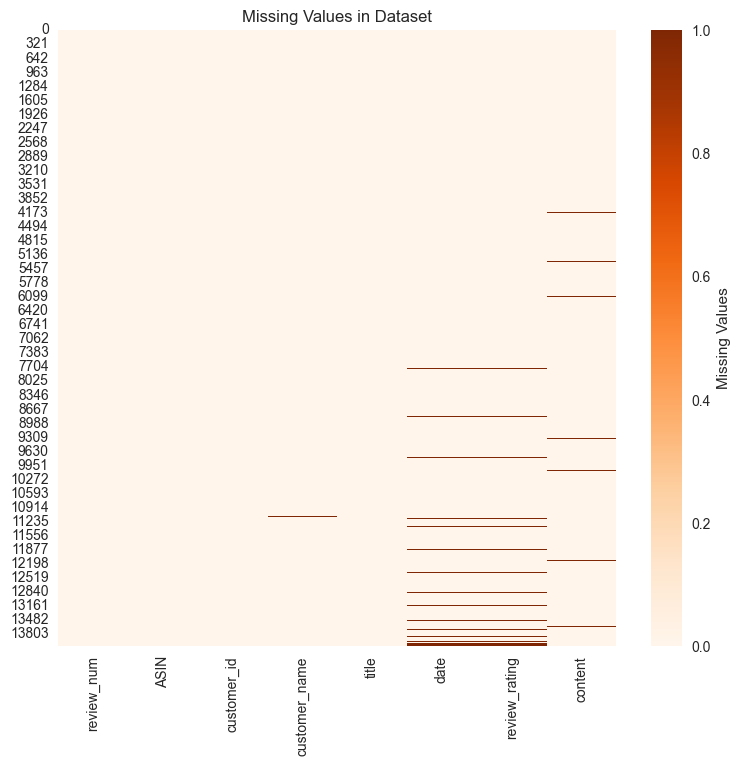

In [25]:
# 결측지 확인 및 처리
df = review_copy
print(df.isnull().sum())

plt.close()
plt.figure(figsize=(9,8))
sns.heatmap(df.isnull(), cbar_kws={'label':'Missing Values'}, cmap='Oranges')
plt.title('Missing Values in Dataset')

plt.show()

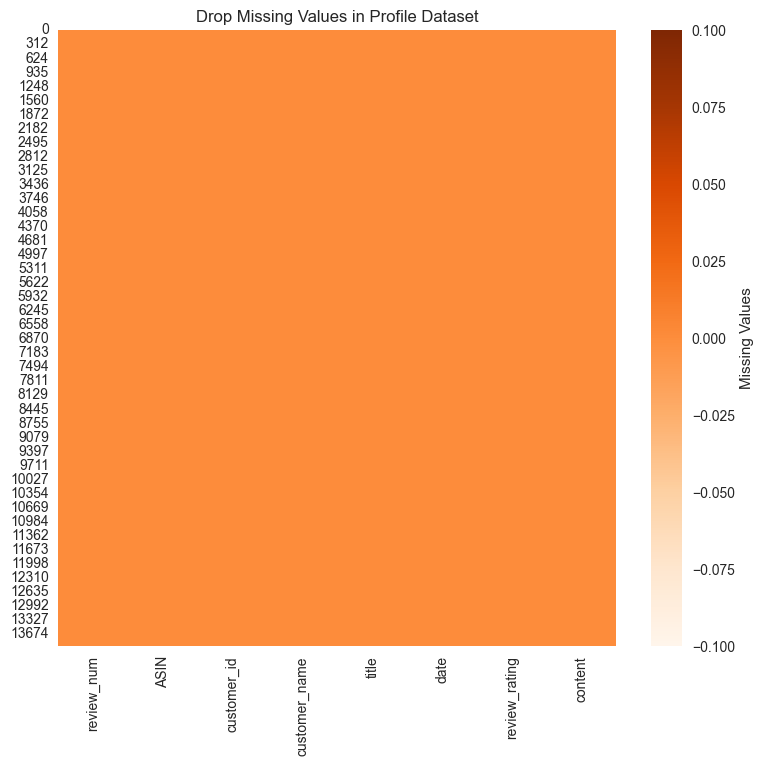

In [26]:
# 결측치 있을 시 처리
review_copy.dropna(inplace=True)
df.isnull().sum()

# 결측치 삭제 확인 시각화 -> 모두균일한 색으로 나오면 없는 것 !
plt.close()
plt.figure(figsize=(9,8))
sns.heatmap(df.isnull(), cbar_kws={'label':'Missing Values'}, cmap='Oranges')
plt.title('Drop Missing Values in Profile Dataset')
plt.show()

> 컬럼 별 전처리

In [28]:
# item_df : detail_dict 컬럼
def preprocess_detail_dict(df_copy):
    
    for i in range(len(df_copy)):
        detail_dict = ast.literal_eval(df_copy.detail_dict[i])
        
        for key, value in detail_dict.items():
            if key not in df_copy.columns:
                df_copy[key] = np.nan
            df_copy.loc[i, key] = value
            
    df_copy.drop(columns=['detail_dict'], inplace=True)
    
    return df_copy.head(2)

preprocess_detail_dict(item_copy)

,ASIN,title,order,category,brand,price,global_rating_count,description,Special_Feature,total_star_mean,best_sellers_rank_Feature,Manufacturer,Country of Origin,Product Dimensions,Is Discontinued By Manufacturer,UPC,Item model number,Department,Package Dimensions,Batteries,Date First Available,Language,Item Weight,Best Sellers Rank,Customer Reviews
0,B000BRKSAO,Alchimie Forever Rejuvenating Eye Balm | Hydra...,109,Personal Care Products,Alchimie Forever,47.00,43,2 in 1 EYE BALM: This hydrating and nourishing...,"Lightweight, Anti Aging",4.1,"#152,144 in Beauty & Personal Care (See Top 10...",Alchimie Forever,USA,2.2 x 2.2 x 4.6 inches; 1 ounces,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,B000PI33IS,"K I.C.O.N. Mane Control, Hairstyling Gel. Give...",77,Hair Care Products,NaN,31.99,14,CONTAIN YOUR MANE: Add shape and definition to...,NaN,5.0,"#193,764 in Beauty & Personal Care (See Top 10...",I.C.O.N.,NaN,NaN,No,794437346182 893627000474 794437342375 9875024...,8436533670175,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
# item_df : best_sellers_rank 컬럼
def preprocess_best_sellers_col(df_copy):

        for i in range(len(df_copy)):
            try:
                value = df_copy.best_sellers_rank_Feature[i]
                
                if pd.isna(value): #np.nan 인 애들
                    # print(f"{i}, {df_copy.best_sellers_rank_Feature[i]} Passed")
                    continue
                
                if isinstance(value, float): # float 타입인 애들
                    value = str(value)
                    print(f"{i}, {df_copy.best_sellers_rank_Feature[i]} Passed")
                
                cat_list = df_copy.best_sellers_rank_Feature[i].split('#')
                
                df_copy.loc[i, 'Category'] = cat_list[1]
                df_copy.loc[i, 'Sub_Category'] = cat_list[2]
                
                detail_list = df_copy.Category[i].split('in')
                
                df_copy.loc[i, 'Category_Rank']= detail_list[0]
                df_copy.loc[i, 'Category_Name']= detail_list[1]
                
                df_copy.loc[i, 'Category_Name'] = df_copy.Category_Name[i].split('(')[0]
                
                sub_list = df_copy.Sub_Category[i].split('in')
                
                df_copy.loc[i, 'Sub_Category_Rank']= sub_list[0]
                df_copy.loc[i, 'Sub_Category_Name']= sub_list[1]
                    
            except Exception as e:
                print(f"{i}, {df_copy.best_sellers_rank_Feature[i]} Passed")
                print(f"Error: {e}")
                
                continue
            
        df_copy.drop(columns=['best_sellers_rank_Feature'], inplace=True)
        return df_copy.head(2)
    
preprocess_best_sellers_col(item_copy)

,ASIN,title,order,category,brand,price,global_rating_count,description,Special_Feature,total_star_mean,Manufacturer,Country of Origin,Product Dimensions,Is Discontinued By Manufacturer,UPC,Item model number,Department,Package Dimensions,Batteries,Date First Available,Language,Item Weight,Best Sellers Rank,Customer Reviews,Category,Sub_Category,Category_Rank,Category_Name,Sub_Category_Rank,Sub_Category_Name
0,B000BRKSAO,Alchimie Forever Rejuvenating Eye Balm | Hydra...,109,Personal Care Products,Alchimie Forever,47.00,43,2 in 1 EYE BALM: This hydrating and nourishing...,"Lightweight, Anti Aging",4.1,Alchimie Forever,USA,2.2 x 2.2 x 4.6 inches; 1 ounces,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"152,144 in Beauty & Personal Care (See Top 100...",30 in Eye Treatment Balms,"152,144",Beauty & Personal Care,30,Eye Treatment Balms
1,B000PI33IS,"K I.C.O.N. Mane Control, Hairstyling Gel. Give...",77,Hair Care Products,NaN,31.99,14,CONTAIN YOUR MANE: Add shape and definition to...,NaN,5.0,I.C.O.N.,NaN,NaN,No,794437346182 893627000474 794437342375 9875024...,8436533670175,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"193,764 in Beauty & Personal Care (See Top 100...","2,323 in Hair Styling Gels","193,764",Beauty & Personal Care,"2,323",Hair Styl


In [43]:
review_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13601 entries, 0 to 14042
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   review_num     13601 non-null  object
 1   ASIN           13601 non-null  object
 2   customer_id    13601 non-null  object
 3   customer_name  13601 non-null  object
 4   title          13601 non-null  object
 5   date           13601 non-null  object
 6   review_rating  13601 non-null  object
 7   content        13601 non-null  object
 8   review_date    13260 non-null  object
dtypes: object(9)
memory usage: 1.5+ MB


In [45]:
review_copy = review_copy.reset_index()

In [47]:
import pandas as pd

def preprocess_review_cols(review_copy):
    # 인덱스 리셋 (연속된 인덱스로 변경)
    review_copy = review_copy.reset_index(drop=True)

    for i in range(len(review_copy)):
        try:
            # 날짜 처리
            if pd.isna(review_copy.loc[i, 'date']) or 'on' not in review_copy.loc[i, 'date']:
                continue
            else:
                review_copy.loc[i, 'review_date'] = review_copy.loc[i, 'date'].split('on')[1].strip()
                review_copy.loc[i, 'review_date'] = pd.to_datetime(review_copy.loc[i, 'review_date'])
            
            # 평점 처리
            if pd.isna(review_copy.loc[i, 'review_rating']):
                continue
            elif isinstance(review_copy.loc[i, 'review_rating'], str):  # 문자열일 경우 변환
                review_copy.loc[i, 'review_rating'] = float(review_copy.loc[i, 'review_rating'].split('out')[0].strip())
        
        except Exception as e:
            print(f"{i}, Error: {e}")
            print(review_copy.iloc[i])  # iloc를 사용해 안전하게 출력
            continue
        
    return review_copy.head(2)

# 테스트 실행
preprocess_review_cols(review_copy)

,index,review_num,ASIN,customer_id,customer_name,title,date,review_rating,content,review_date
0,0,B000BRKSAO__0,B000BRKSAO,RRY2LMDB8KM5H,Mrsblue,Alchimie Forever Rejuvenating Eye Balm | Hydra...,"Reviewed in the United States on April 10, 2024",5.0,This is the best product I've ever used under ...,2024-04-10 00:00:00
1,1,B000BRKSAO__1,B000BRKSAO,R2KU89UAY0VLM2,Marsh Christmas,Alchimie Forever Rejuvenating Eye Balm | Hydra...,"Reviewed in the United States on June 5, 2022",5.0,Morning and night for 5 days and the dark line...,2022-06-05 00:00:00


In [48]:
review_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13601 entries, 0 to 13600
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   index          13601 non-null  int64 
 1   review_num     13601 non-null  object
 2   ASIN           13601 non-null  object
 3   customer_id    13601 non-null  object
 4   customer_name  13601 non-null  object
 5   title          13601 non-null  object
 6   date           13601 non-null  object
 7   review_rating  13601 non-null  object
 8   content        13601 non-null  object
 9   review_date    13601 non-null  object
dtypes: int64(1), object(9)
memory usage: 1.0+ MB


### Base Data

In [51]:
# item_df와 review_df를 ASIN 기준으로 merge
amazon_df = pd.merge(item_copy, review_copy, on='ASIN')
amazon_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13601 entries, 0 to 13600
Data columns (total 39 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   ASIN                             13601 non-null  object 
 1   title_x                          13601 non-null  object 
 2   order                            13601 non-null  int64  
 3   category                         13601 non-null  object 
 4   brand                            11217 non-null  object 
 5   price                            13599 non-null  float64
 6   global_rating_count              13601 non-null  object 
 7   description                      12945 non-null  object 
 8   Special_Feature                  3247 non-null   object 
 9   total_star_mean                  13601 non-null  float64
 10  Manufacturer                     12755 non-null  object 
 11  Country of Origin                7222 non-null   object 
 12  Product Dimensions

In [52]:
amazon_df.rename(columns={'content':'review_content', 'title_x':'title'}, inplace=True)
amazon_df.drop(['title_y'], axis=1, inplace=True)
amazon_df.reset_index(drop=True, inplace=True)
amazon_df.isnull().sum()

ASIN                                   0
title                                  0
order                                  0
category                               0
brand                               2384
price                                  2
global_rating_count                    0
description                          656
Special_Feature                    10354
total_star_mean                        0
Manufacturer                         846
Country of Origin                   6379
Product Dimensions                  5913
Is Discontinued By Manufacturer    10772
UPC                                 9575
Item model number                   7152
Department                         13507
Package Dimensions                  8082
Batteries                          13381
Date First Available               11882
Language                           13601
Item Weight                        13579
Best Sellers Rank                  13506
Customer Reviews                   13465
Category        

In [53]:
# Category_Rank
amazon_df['Category_Rank'] = amazon_df['Category_Rank'].apply(
    lambda x: str(x).replace(',', '') if not pd.isna(x) and isinstance(x, float) else x
).astype('str').apply(lambda x: x.replace(',', '') if x != 'nan' else None)

# Sub_Category_Rank
amazon_df['Sub_Category_Rank'] = amazon_df['Sub_Category_Rank'].apply(
    lambda x: str(x).replace(',', '') if not pd.isna(x) and isinstance(x, float) else x
).astype('str').apply(lambda x: x.replace(',', '') if x != 'nan' else None)

# review_rating
amazon_df['review_rating'] = amazon_df['review_rating'].apply(
    lambda x: str(x) if not pd.isna(x) and isinstance(x, float) else x
).astype('float', errors='ignore')

# review_date
amazon_df['review_date'] = amazon_df['review_date'].apply(
    lambda x: pd.to_datetime(x) if not pd.isna(x) else None
)

In [58]:
# 한국에서 만들어진 아이템들만
amazon_df = amazon_df[amazon_df['Country of Origin']=='Korea, Republic of']
amazon_df.reset_index(drop=True, inplace=True)

amazon_df.info()
amazon_df.head(5)
# amazon_df.to_csv(DATA_PATH + 'amazon_df_0116.csv', encoding='utf-8')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5148 entries, 0 to 5147
Data columns (total 39 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   ASIN                             5148 non-null   object        
 1   title                            5148 non-null   object        
 2   order                            5148 non-null   int64         
 3   category                         5148 non-null   object        
 4   brand                            4272 non-null   object        
 5   price                            5148 non-null   float64       
 6   global_rating_count              5148 non-null   object        
 7   description                      5048 non-null   object        
 8   Special_Feature                  1006 non-null   object        
 9   total_star_mean                  5148 non-null   float64       
 10  Manufacturer                     4977 non-null   object     

,ASIN,title,order,category,brand,price,global_rating_count,description,Special_Feature,total_star_mean,Manufacturer,Country of Origin,Product Dimensions,Is Discontinued By Manufacturer,UPC,Item model number,Department,Package Dimensions,Batteries,Date First Available,Language,Item Weight,Best Sellers Rank,Customer Reviews,Category,Sub_Category,Category_Rank,Category_Name,Sub_Category_Rank,Sub_Category_Name,index,review_num,customer_id,customer_name,date,review_rating,review_content,review_date,detected_language
0,B003YUW0ZG,ATOPALM Moisturizing Hand Treatment hydrate so...,19,"Foot, Hand & Nail Care Products",ATOPALM,9.6,33,[No.1 K-Beauty Brand] No. 1 Brand Power Index ...,Lightweight,4.6,NeoPharm Co. Ltd,"Korea, Republic of",1.75 x 1.75 x 6.5 inches; 0.96 ounces,No,857811002057,22229043,Skin Care,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"121,462 in Beauty & Personal Care (See Top 100...",623 in Hand Creams & Lotions,121462,Beauty & Personal Care,623,Hand Creams & Lotions,124,B003YUW0ZG__0,R1609OKLLIPGJS,tngirl,"Reviewed in the United States on November 12, ...",5.0,This lotion is one of my favorites. Super mois...,2023-11-12,en
1,B003YUW0ZG,ATOPALM Moisturizing Hand Treatment hydrate so...,19,"Foot, Hand & Nail Care Products",ATOPALM,9.6,33,[No.1 K-Beauty Brand] No. 1 Brand Power Index ...,Lightweight,4.6,NeoPharm Co. Ltd,"Korea, Republic of",1.75 x 1.75 x 6.5 inches; 0.96 ounces,No,857811002057,22229043,Skin Care,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"121,462 in Beauty & Personal Care (See Top 100...",623 in Hand Creams & Lotions,121462,Beauty & Personal Care,623,Hand Creams & Lotions,125,B003YUW0ZG__1,R2PCHJMLLY1GA,mamanaka,"Reviewed in the United States on March 17, 2023",5.0,If you wash your hands frequently due to work ...,2023-03-17,en
2,B003YUW0ZG,ATOPALM Moisturizing Hand Treatment hydrate so...,19,"Foot, Hand & Nail Care Products",ATOPALM,9.6,33,[No.1 K-Beauty Brand] No. 1 Brand Power Index ...,Lightweight,4.6,NeoPharm Co. Ltd,"Korea, Republic of",1.75 x 1.75 x 6.5 inches; 0.96 ounces,No,857811002057,22229043,Skin Care,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"121,462 in Beauty & Personal Care (See Top 100...",623 in Hand Creams & Lotions,121462,Beauty & Personal Care,623,Hand Creams & Lotions,126,B003YUW0ZG__2,R3R24S91QP590J,Eric G.,"Reviewed in the United States on November 7, 2022",5.0,Works great. Helps with eczema. Soaks I’m. Doe...,2022-11-07,en
3,B003YUW0ZG,ATOPALM Moisturizing Hand Treatment hydrate so...,19,"Foot, Hand & Nail Care Products",ATOPALM,9.6,33,[No.1 K-Beauty Brand] No. 1 Brand Power Index ...,Lightweight,4.6,NeoPharm Co. Ltd,"Korea, Republic of",1.75 x 1.75 x 6.5 inches; 0.96 ounces,No,857811002057,22229043,Skin Care,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"121,462 in Beauty & Personal Care (See Top 100...",623 in Hand Creams & Lotions,121462,Beauty & Personal Care,623,Hand Creams & Lotions,127,B003YUW0ZG__3,R1OPH4W6UYITO3,Big Spender,"Reviewed in the United States on July 20, 2014",4.0,Very moisturizing and long lasting. Wear it on...,2014-07-20,en
4,B003YUW0ZG,ATOPALM Moisturizing Hand Treatment hydrate so...,19,"Foot, Hand & Nail Care Products",ATOPALM,9.6,33,[No.1 K-Beauty Brand] No. 1 Brand Power Index ...,Lightweight,4.6,NeoPharm Co. Ltd,"Korea, Republic of",1.75 x 1.75 x 6.5 inches; 0.96 ounces,No,857811002057,22229043,Skin Care,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"121,462 in Beauty & Personal Care (See Top 100...",623 in Hand Creams & Lotions,121462,Beauty & Personal Care,623,Hand Creams & Lotions,128,B003YUW0ZG__4,R34I37566RO17F,Kyle Cook,"Reviewed in the United States on January 14, 2014",4.0,"Good product, can tell there is quality in it....",2014-01-14,en


In [62]:
amazon_df.review_content.loc[2]

'Works great. Helps with eczema. Soaks I’m. Does not leave hands greasy. Best over the counter cream for eczema.'

> 텍스트 데이터 전처리

In [55]:
from langdetect import detect
from langdetect.lang_detect_exception import LangDetectException
from deep_translator import GoogleTranslator

def detect_language(text):
    try:
        return detect(text)
    except LangDetectException:
        return 'unknown'


def translate_en(text):
    to_translate = text
    translated = GoogleTranslator(source='auto', target='english').translate(to_translate)
    return translated

# 리뷰 언어가 영어가 아닌 경우 -> 번역
amazon_df['detected_language'] = amazon_df['review_content'].apply(detect_language)
amazon_df.loc[amazon_df['detected_language'] != 'en', 'review_content'] = amazon_df.loc[amazon_df['detected_language'] != 'en', 'review_content'].apply(translate_en)

# amazon_df.to_csv(DATA_PATH + AMAZON / 'amazon_koreaOnly_translated.csv', encoding='utf-8')

In [63]:
# nltk 에서 Punkt tokenizer & stopwords list를 다운로드
import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to /Users/jun/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /Users/jun/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [66]:
# porter stemmer 초기화 및 영어 불용어 세트 생성 (캐클 참고)
import re
import string

def preprocess_en():
    
    stemmer = PorterStemmer()
    stop_words = set(stopwords.words('english'))  

    # 텍스트 전처리
    def clean_text(text):
        if isinstance(text, str):
        
            # 소문자로 모두 변환환
            text = text.lower()

            # URL 제거
            text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

            # 마크다운 스타일 링크 제거
            text = re.sub(r'\[.*?\]\(.*?\)', '', text)

            # @ 제거
            text = re.sub(r'@\w+', '', text)

            # 구두점, 특수문자 제거
            text = text.translate(str.maketrans('', '', string.punctuation))

            return text
        else:
            return text

    # 텍스트 토큰화
    def tokenize_text(text):
        if isinstance(text, str):
            return word_tokenize(text)
        else:
            return text

    # 불용어 제거
    def remove_stopwords(tokens):
        if isinstance(tokens, list):
            return [word for word in tokens if word not in stop_words]
        else:
            return tokens

    # -> stemming 함수 추가 (이거를 위에꺼랑 합쳐서?)
    def stem_tokens(tokens):
        if isinstance(tokens, list):
            return [stemmer.stem(token) for token in tokens]
        else:
            return tokens

    # 저장
    amazon_df['cleaned_title'] = amazon_df['title'].apply(clean_text)
    amazon_df['cleaned_review'] = amazon_df['review_content'].apply(clean_text)

    amazon_df['tokenized_title'] = amazon_df['title'].apply(tokenize_text)
    amazon_df['tokenized_review'] = amazon_df['cleaned_review'].apply(tokenize_text)

    amazon_df['stemmed_title'] = amazon_df['tokenized_title'].apply(stem_tokens)
    amazon_df['stemmed_review'] = amazon_df['tokenized_review'].apply(stem_tokens) 

    amazon_df['stpw_processed_title'] = amazon_df['tokenized_title'].apply(remove_stopwords)
    amazon_df['stpw_processed_review'] = amazon_df['tokenized_review'].apply(remove_stopwords)

    amazon_df.head(2)

In [67]:
preprocess_en()

In [71]:
amazon_df.stpw_processed_review.loc[2]

['works',
 'great',
 'helps',
 'eczema',
 'soaks',
 '’',
 'leave',
 'hands',
 'greasy',
 'best',
 'counter',
 'cream',
 'eczema']

# PART 2: EDA

### ◼ Amazon

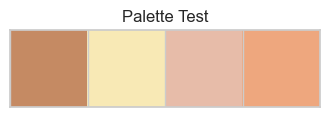

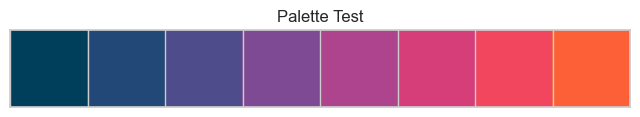

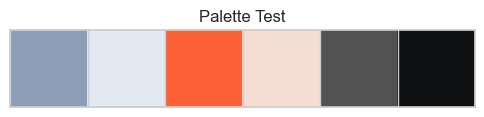

In [72]:
# 색깔 정해야함..
from matplotlib.colors import LinearSegmentedColormap

beauty_palette = ['#C58A63', '#F8E9B5', '#E7BCA9', '#EEA77E']
market_palette = ["#003f5c", "#214876", "#4e4c8a", "#7e4a93", "#ae448d", "#d63e7a", "#f1465d", "#fd6036"]
# market_palette = ['#003f5c', '#354b72', '#5f5682', '#875f8a', '#ac6b8c', '#cb7a88', '#e18e82', '#eea77e']

skin_palette = ['#8C9DB7', '#E3E9F2', '#FD6036','#F6DDD3', '#525252', '#0E1012']

custom_cmap = LinearSegmentedColormap.from_list("custom_palette", market_palette)

sns.palplot(beauty_palette)
plt.title("Palette Test")
plt.show()

sns.palplot(market_palette)
plt.title("Palette Test")
plt.show()

sns.palplot(skin_palette)
plt.title("Palette Test")
plt.show()

> K-beauty 하위 카테고리 및 브랜드 구성 확인

In [76]:
### 분포 ###
# K-beauty 하위 카테고리 별 리뷰 개수
category_count = pd.DataFrame(amazon_df.Sub_Category_Name.value_counts())
category_count.reset_index(inplace=True)
category_count.columns = ['Sub_Category', 'Count']
category_count.head(10)

,Sub_Category,Count
0,Facial Serums,860
1,Face Moisturizers,590
2,Facial Masks,468
3,Facial Toners & Astr,312
4,Manicure & Pedicure Kits,221
5,Facial Cleans,217
6,Lip Sta,161
7,Makeup Cleans,145
8,Facial Night Creams,144
9,Eye Wr,139


In [75]:
# K-beauty 브랜드 별 리뷰 개수 (상품 수로 추정 또는 상품 수는 직접 사이트 들어가서 눌러보고 ㅎ 컬럼 별로 입력)
amazon_df.brand.unique()

array(['ATOPALM', 'Three Seven (777)', nan, 'Memoir Cosmetics', 'SONGWOL',
       'SeoulCeuticals', 'Sooryehan', 'ESSENHERB', 'estheSKIN',
       'MAXCLINIC', "A'PIEU", 'SNP Shining Nature Purity',
       "IT'S MY CUSHION", 'Meebak', 'BOTANITY', 'BLITHE', 'varuza',
       'Naturally', "I'm from", 'Pyunkang Yul', 'FRUDIA', 'ma:nyo',
       'BENTON', 'Real Barrier', 'Dr.G', 'Torriden', 'beplain',
       'RAWQUEST', 'JOAH', 'COLORGRAM', 'INCELLDERM', 'K-SECRET',
       'Beauty of Joseon', 'Generic', 'Innerest', 'UNOVE', 'dr.pepti',
       'SKIN & LAB SKIN SCIENCE SOLUTION', 'BBI@ BBIA', 'JAXON LANE',
       'HOLIKA HOLIKA', 'BE+WANTS', 'DWEasyDerm', 'jmella',
       'Daeng Gi Meo Ri', 'Lamelin', 'FADETTE', 'molvany', 'ZIOSTAND',
       'QFORET', 'lilybyred', 'Avajar', 'MUZIGAE MANSION', 'GOOLITTER',
       'J.CAT BEAUTY', 'MUZMAK', 'Peripera', 'borntree', 'IRECIPE',
       'THESAEM', 'Peach C', 'WHITESILK', 'Intermission',
       "That's What She Used", 'herbloom', 'HONEY ZIP', 'Hanyul',


In [77]:
# 브랜드 별 리뷰 개수 (상위 30개)
k_brand_count = pd.DataFrame(amazon_df.brand.value_counts().head(31))
k_brand_count.reset_index(inplace=True)
k_brand_count.columns = ['brand', 'count']
k_brand_count.drop(0, axis=0, inplace=True)

top30_list = k_brand_count.brand.unique()
top30_list
# k_brand_count.head()

array(['Three Seven (777)', 'PURITO', 'SNP Shining Nature Purity', 'Dr.G',
       'beplain', 'Meebak', 'Pyunkang Yul', "A'PIEU", 'Peripera',
       'DWEasyDerm', 'Innerest', 'VEGAN J.', 'MUZIGAE MANSION',
       'Memoir Cosmetics', 'MAXCLINIC', "I'm from", 'Avajar', 'COLORGRAM',
       'SKIN & LAB SKIN SCIENCE SOLUTION', 'SU:M', 'Beauty of Joseon',
       'glowiest', 'HOLIKA HOLIKA', 'THESAEM', 'Real Barrier',
       'I DEW CARE', 'Torriden', 'Lamelin', 'ESSENHERB', 'Elizabeth Mott'],
      dtype=object)

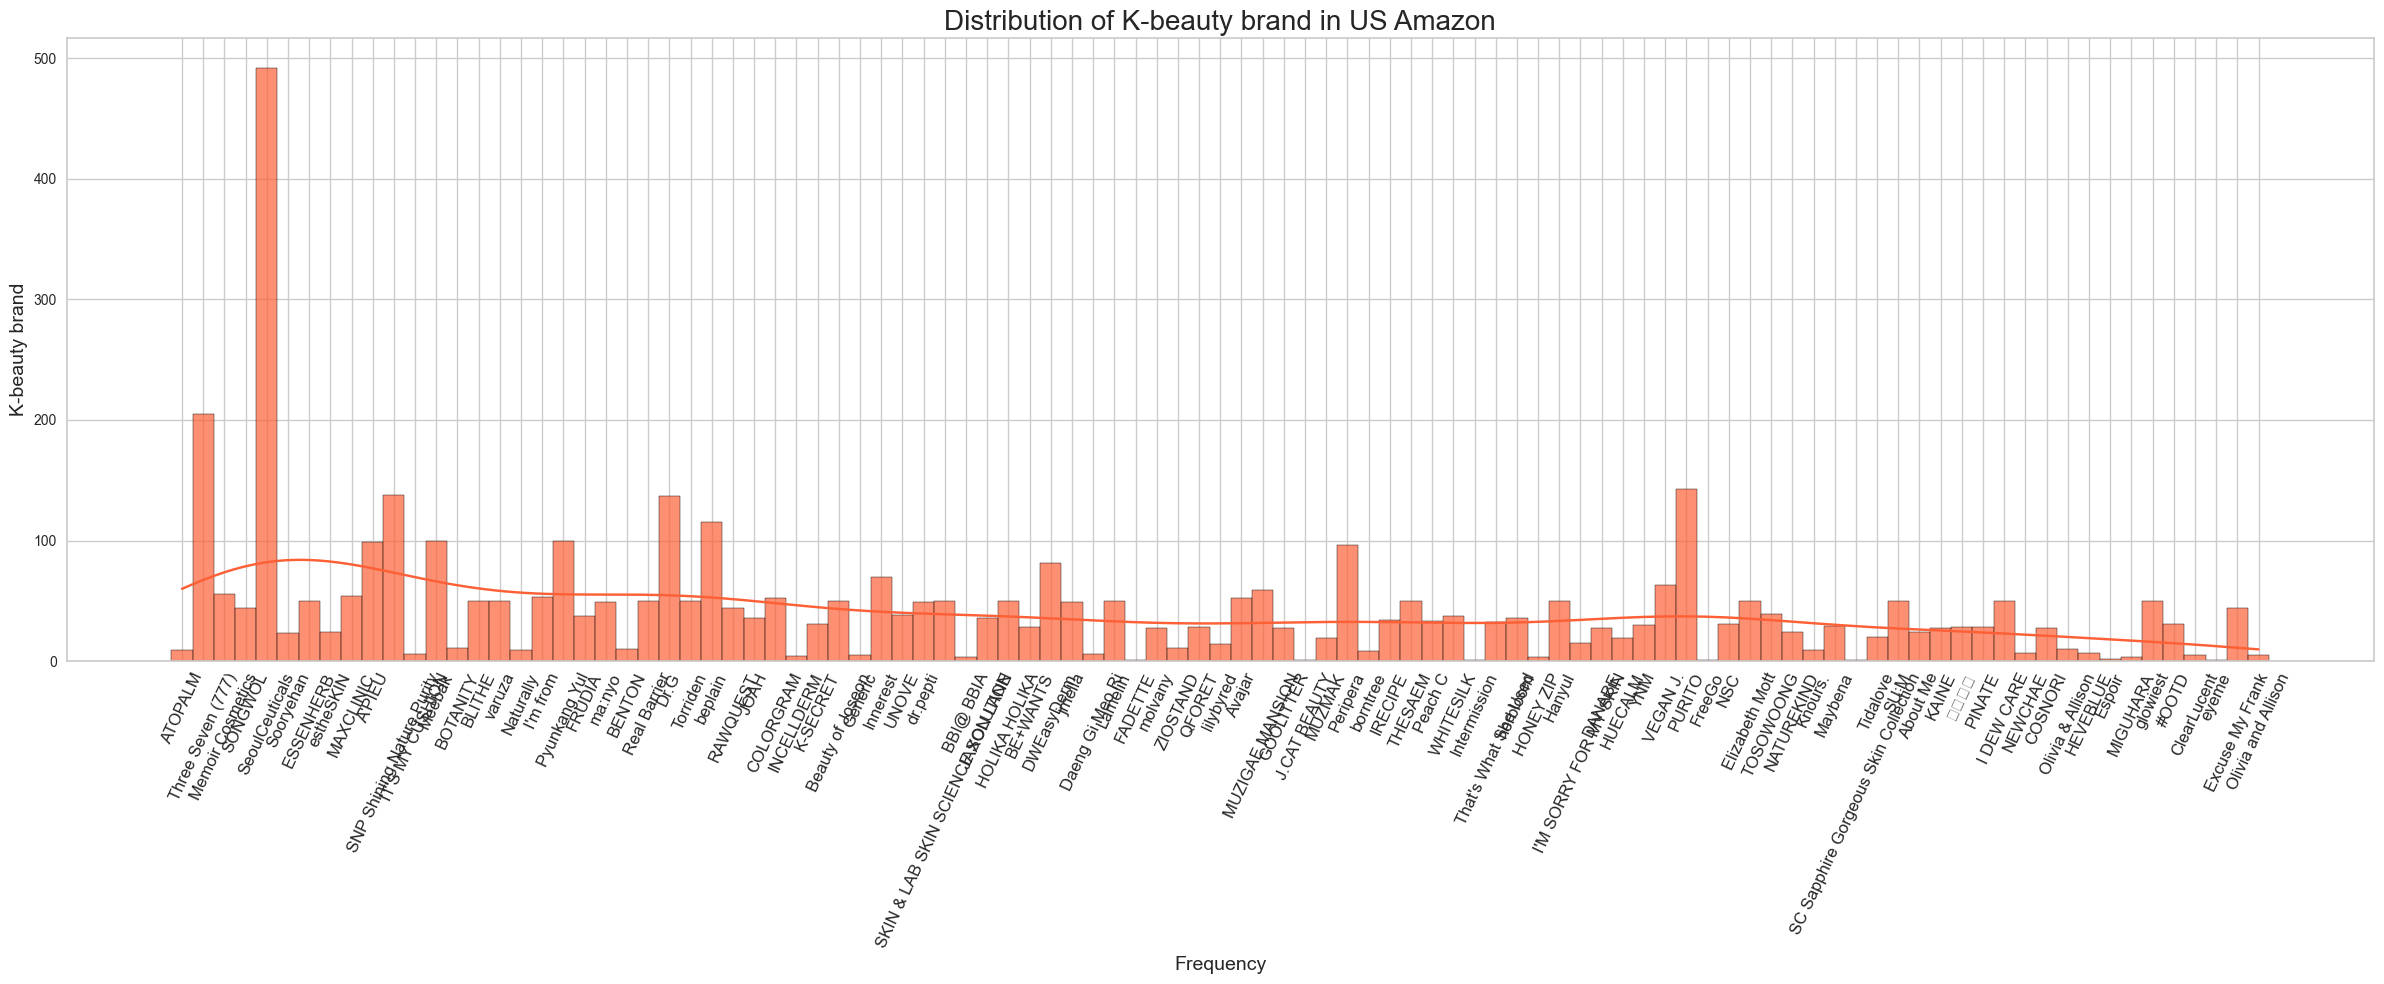

In [78]:
# 브랜드 분포
plt.figure(figsize=(24,10))
sns.histplot(data=amazon_df, x='brand', color='#FD6036', alpha=0.7, kde=True)
plt.title('Distribution of K-beauty brand in US Amazon', fontsize=20)

plt.xticks(rotation=65, fontsize=12)
plt.xlabel('Frequency', fontsize=14)
plt.ylabel('K-beauty brand', fontsize=14)

plt.tight_layout()
plt.show()

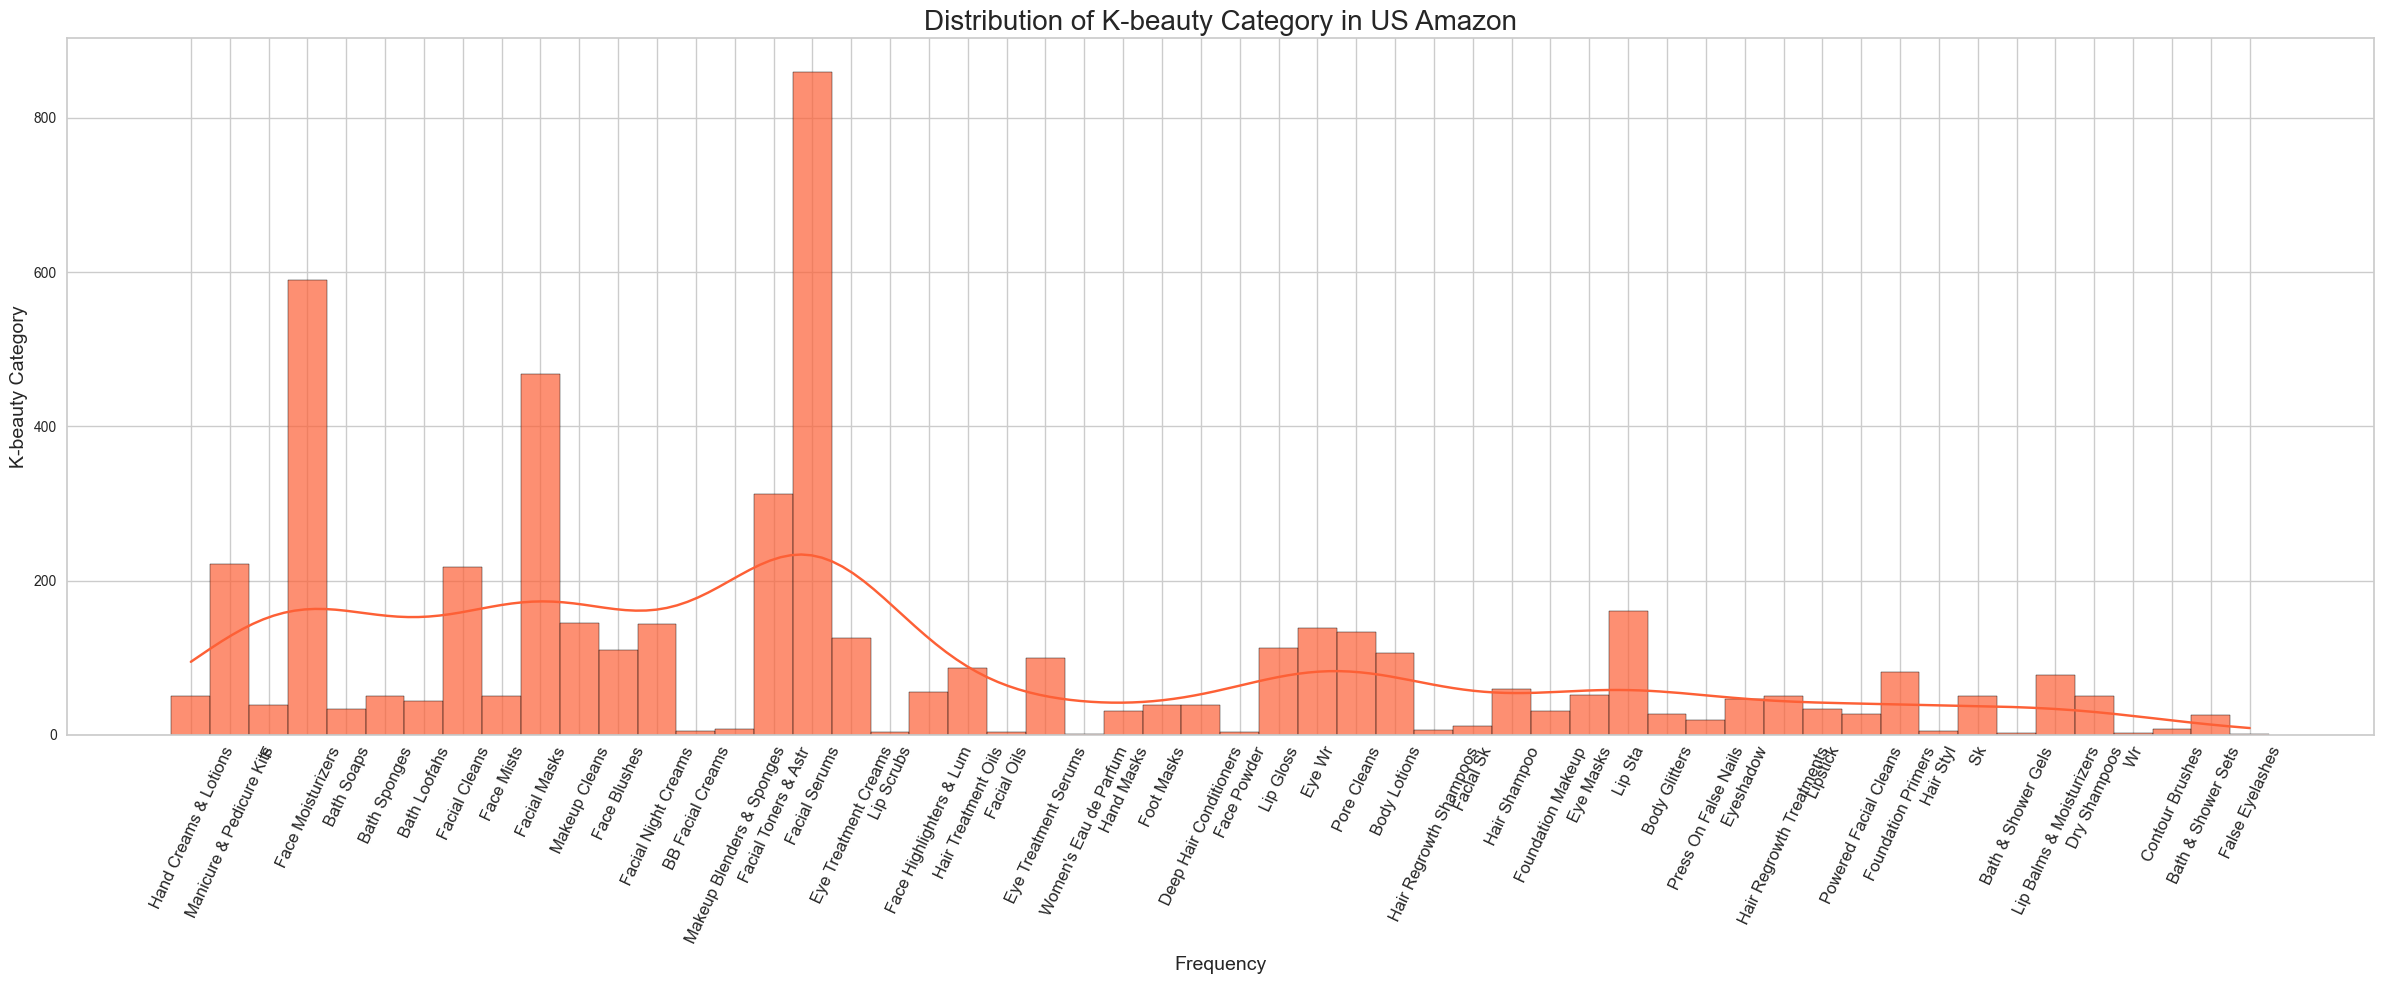

In [79]:
# 카테고리 분포
plt.figure(figsize=(24,10))
sns.histplot(data=amazon_df['Sub_Category_Name'], bins=31, alpha=0.7, color='#FD6036', kde=True)
plt.title('Distribution of K-beauty Category in US Amazon', fontsize=20)

plt.xticks(rotation=65, fontsize=12)
plt.xlabel('Frequency', fontsize=14)
plt.ylabel('K-beauty Category', fontsize=14)

plt.tight_layout()
plt.show()

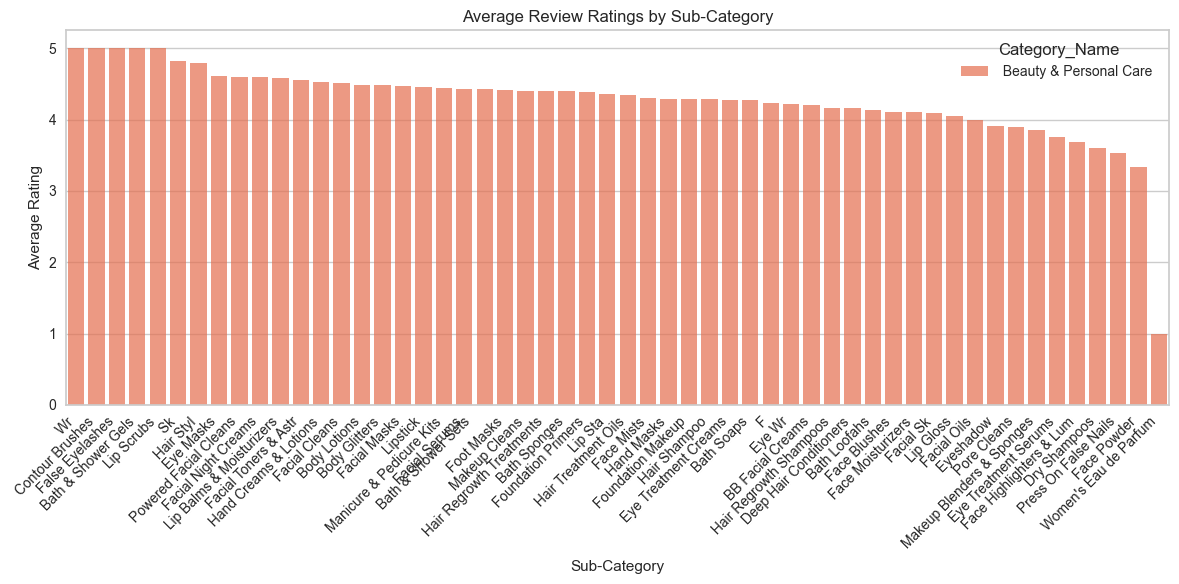

In [81]:
### 평점 평균 ###
# 카테고리별
category_mean = pd.pivot_table(amazon_df, index=['Category_Name', 'Sub_Category_Name'], values='review_rating', aggfunc='mean')
category_mean = category_mean.reset_index().sort_values(by='review_rating', ascending=False)

# 브랜드 별
brand_review_score = pd.pivot_table(amazon_df, index=['brand'], values='review_rating', aggfunc='mean')
brand_review_score = brand_review_score.reset_index().sort_values(by='review_rating', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=category_mean, x='Sub_Category_Name', y='review_rating', hue='Category_Name', dodge=False, palette=market_palette[-1::-1], alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.title('Average Review Ratings by Sub-Category')
plt.ylabel('Average Rating')
plt.xlabel('Sub-Category')
plt.tight_layout()
plt.show()


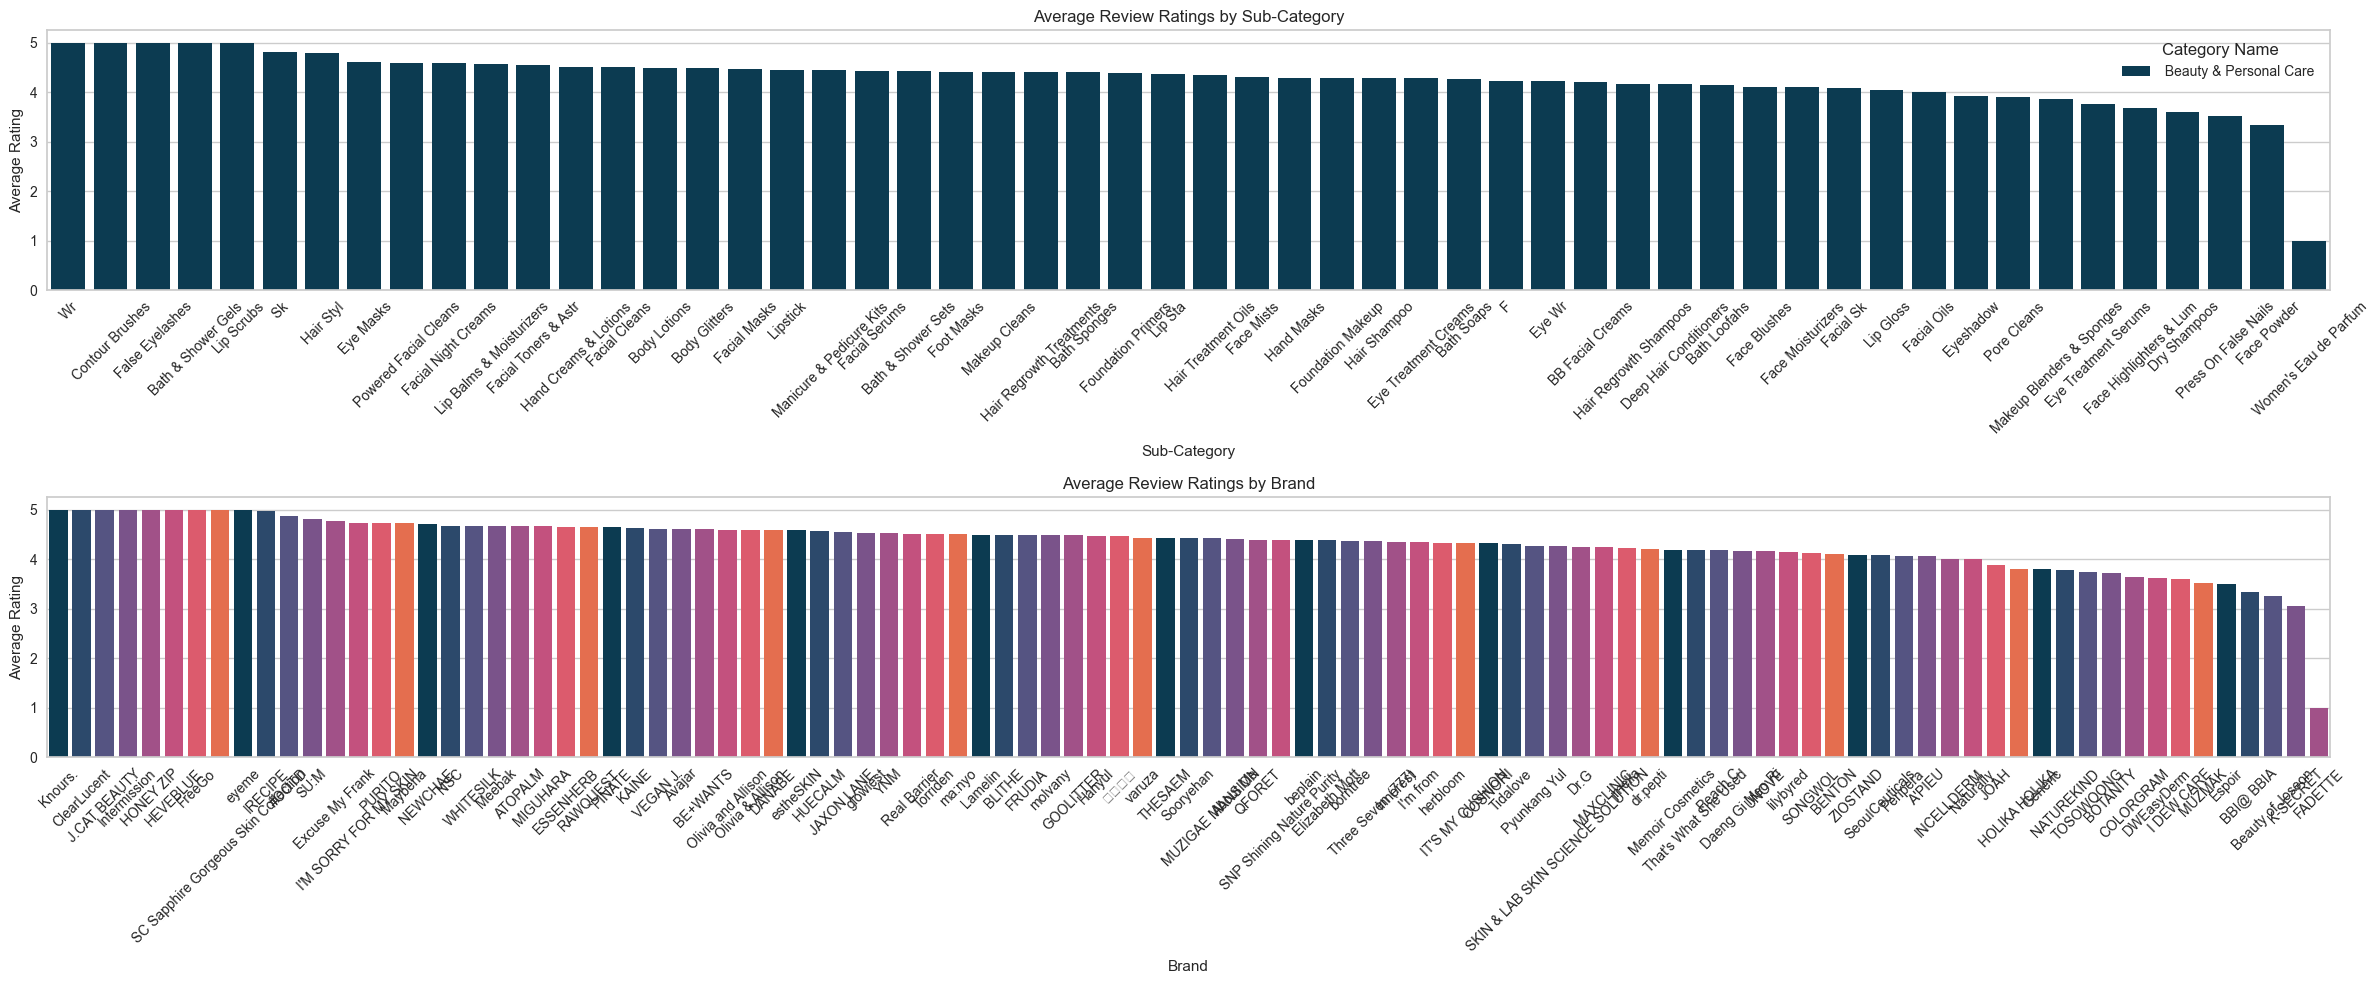

In [82]:
# K-beauty 하위 카테고리와 브랜드 별 리뷰 평점 평균 시각화
import itertools
plt.close()

num_bars = 54
extended_palette = list(itertools.islice(itertools.cycle(market_palette), num_bars))

fig, axes = plt.subplots(2, 1, figsize=(24, 10), sharex=False)

# 1. 카테고리별 Sub-Category 평점 평균
sns.barplot(
    data=category_mean, 
    x='Sub_Category_Name', 
    y='review_rating', 
    hue='Category_Name', 
    dodge=False, 
    palette=extended_palette, 
    ax=axes[0]
)
axes[0].set_title('Average Review Ratings by Sub-Category')
axes[0].set_ylabel('Average Rating')
axes[0].set_xlabel('Sub-Category')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Category Name')

# 2. 브랜드별 평점 평균
sns.barplot(
    data=brand_review_score, 
    x='brand', 
    y='review_rating', 
    palette=extended_palette, 
    ax=axes[1]
)
axes[1].set_title('Average Review Ratings by Brand')
axes[1].set_ylabel('Average Rating')
axes[1].set_xlabel('Brand')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [83]:
import plotly.graph_objects as go

df = brand_review_score.head(30)

fig = go.Figure(data=[go.Table(
    header=dict(values=df.columns, fill_color='paleturquoise', align='center'),
    cells=dict(values=[df[col] for col in df.columns], fill_color='lavender', align='center'))
])

fig.update_layout(title='Brand Review Scores')
fig.show()

In [86]:
# 전반적인 상관관계
plt.close()

sns.reset_defaults()
plt.rcdefaults()
plt.style.use('default')
plt.figure(figsize=(8,6))

sample_data = amazon_df.select_dtypes(include=["number"])
sample_data.head()

,order,price,total_star_mean,index,review_rating
0,19,9.6,4.6,124,5.0
1,19,9.6,4.6,125,5.0
2,19,9.6,4.6,126,5.0
3,19,9.6,4.6,127,4.0
4,19,9.6,4.6,128,4.0


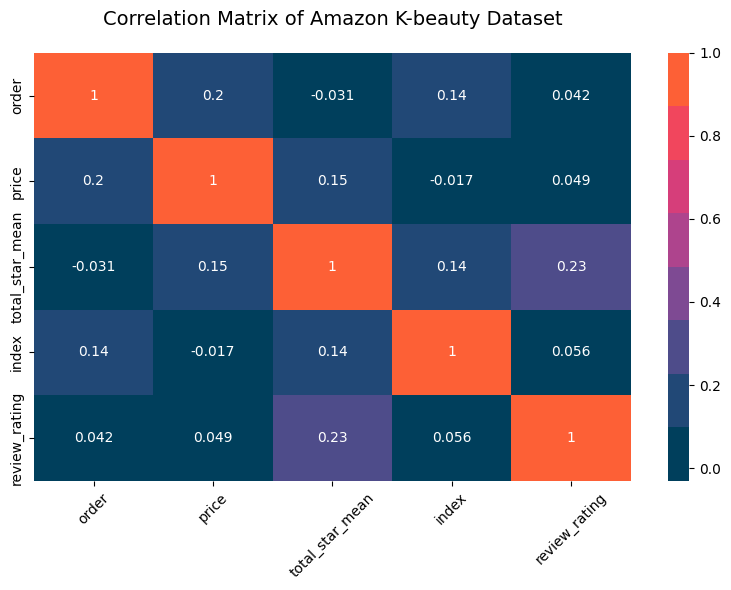

In [ ]:
#compute correlation
corr_matrix = sample_data.corr()
corr_matrix

#annot=True return the correlation values
sns.heatmap(corr_matrix, cmap=market_palette, annot=True)
plt.xticks(rotation=45)
plt.title('Correlation Matrix of Amazon K-beauty Dataset', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

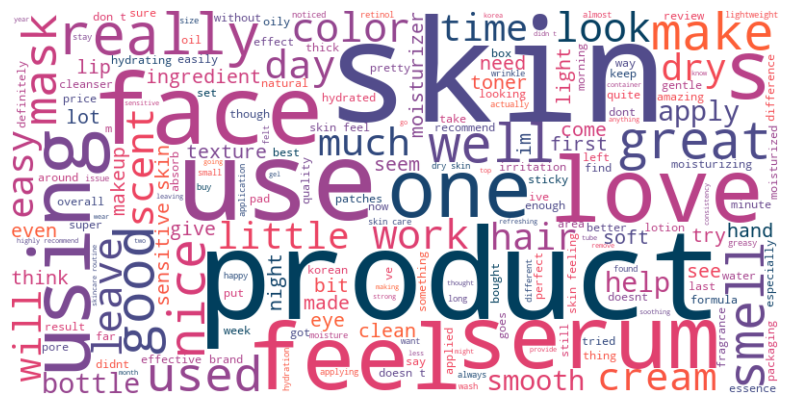

In [85]:
from wordcloud import WordCloud

# 전처리된 리뷰 워드 클라우드
wordcloud = WordCloud(width=800, height=400, 
                    background_color='white', colormap=custom_cmap).generate(' '.join(amazon_df['cleaned_review'].dropna()))
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
# plt.title("Word Cloud - Item Review")
plt.show()

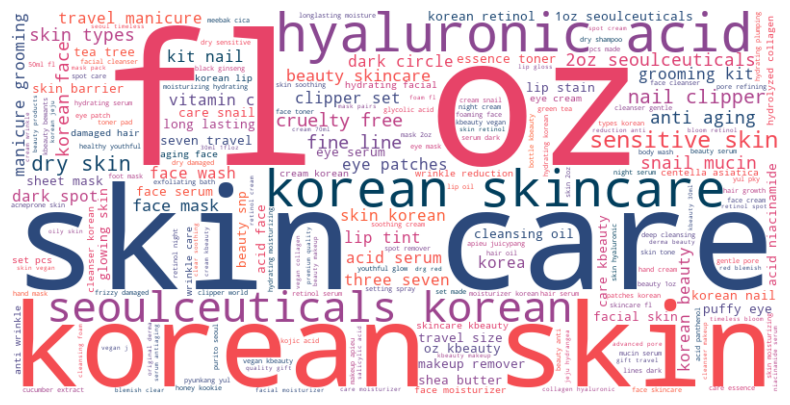

In [88]:
# 전처리된 상품 제목 (아이템 이름) 워드 클라우드
wordcloud = WordCloud(width=800, height=400, 
                      background_color='white', colormap=custom_cmap).generate(' '.join(amazon_df['cleaned_title'].dropna()))
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
# plt.title("Word Cloud - Item Title")
plt.show()

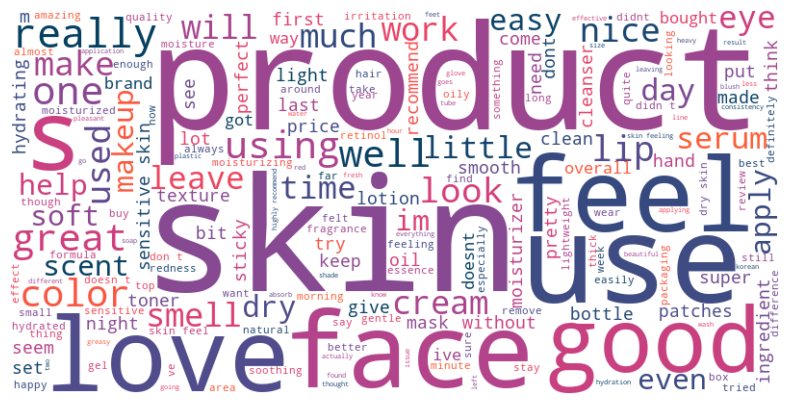

In [89]:
# top 30 브랜드 (리뷰 수 기준임, 평점 기준도 확인 필요) - 리뷰 내용 워드 클라우드
query_cond = amazon_df['brand'].isin(top30_list)
top_df = amazon_df[query_cond]

wordcloud = WordCloud(width=800, height=400, 
                      background_color='white', colormap=custom_cmap).generate(' '.join(top_df['cleaned_review'].dropna()))
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
# plt.title("Word Cloud - Item Title")
plt.show()

### ◼ Skinsort

In [90]:
import plotly.express as px
import plotly.io as pio

df = skinsort_copy

country_dist = df['country'].value_counts().reset_index()
country_dist.columns = ['Country', 'Count']

fig = px.pie(country_dist[:15], values='Count', names='Country', title=f"Country Distribution for Skinsort Brand Data")
fig.update_traces(hole=.3)
# imgname = "skinsort_country_distribution.png"
# fig.write_image(DATA_PATH+imgname)
fig.show()

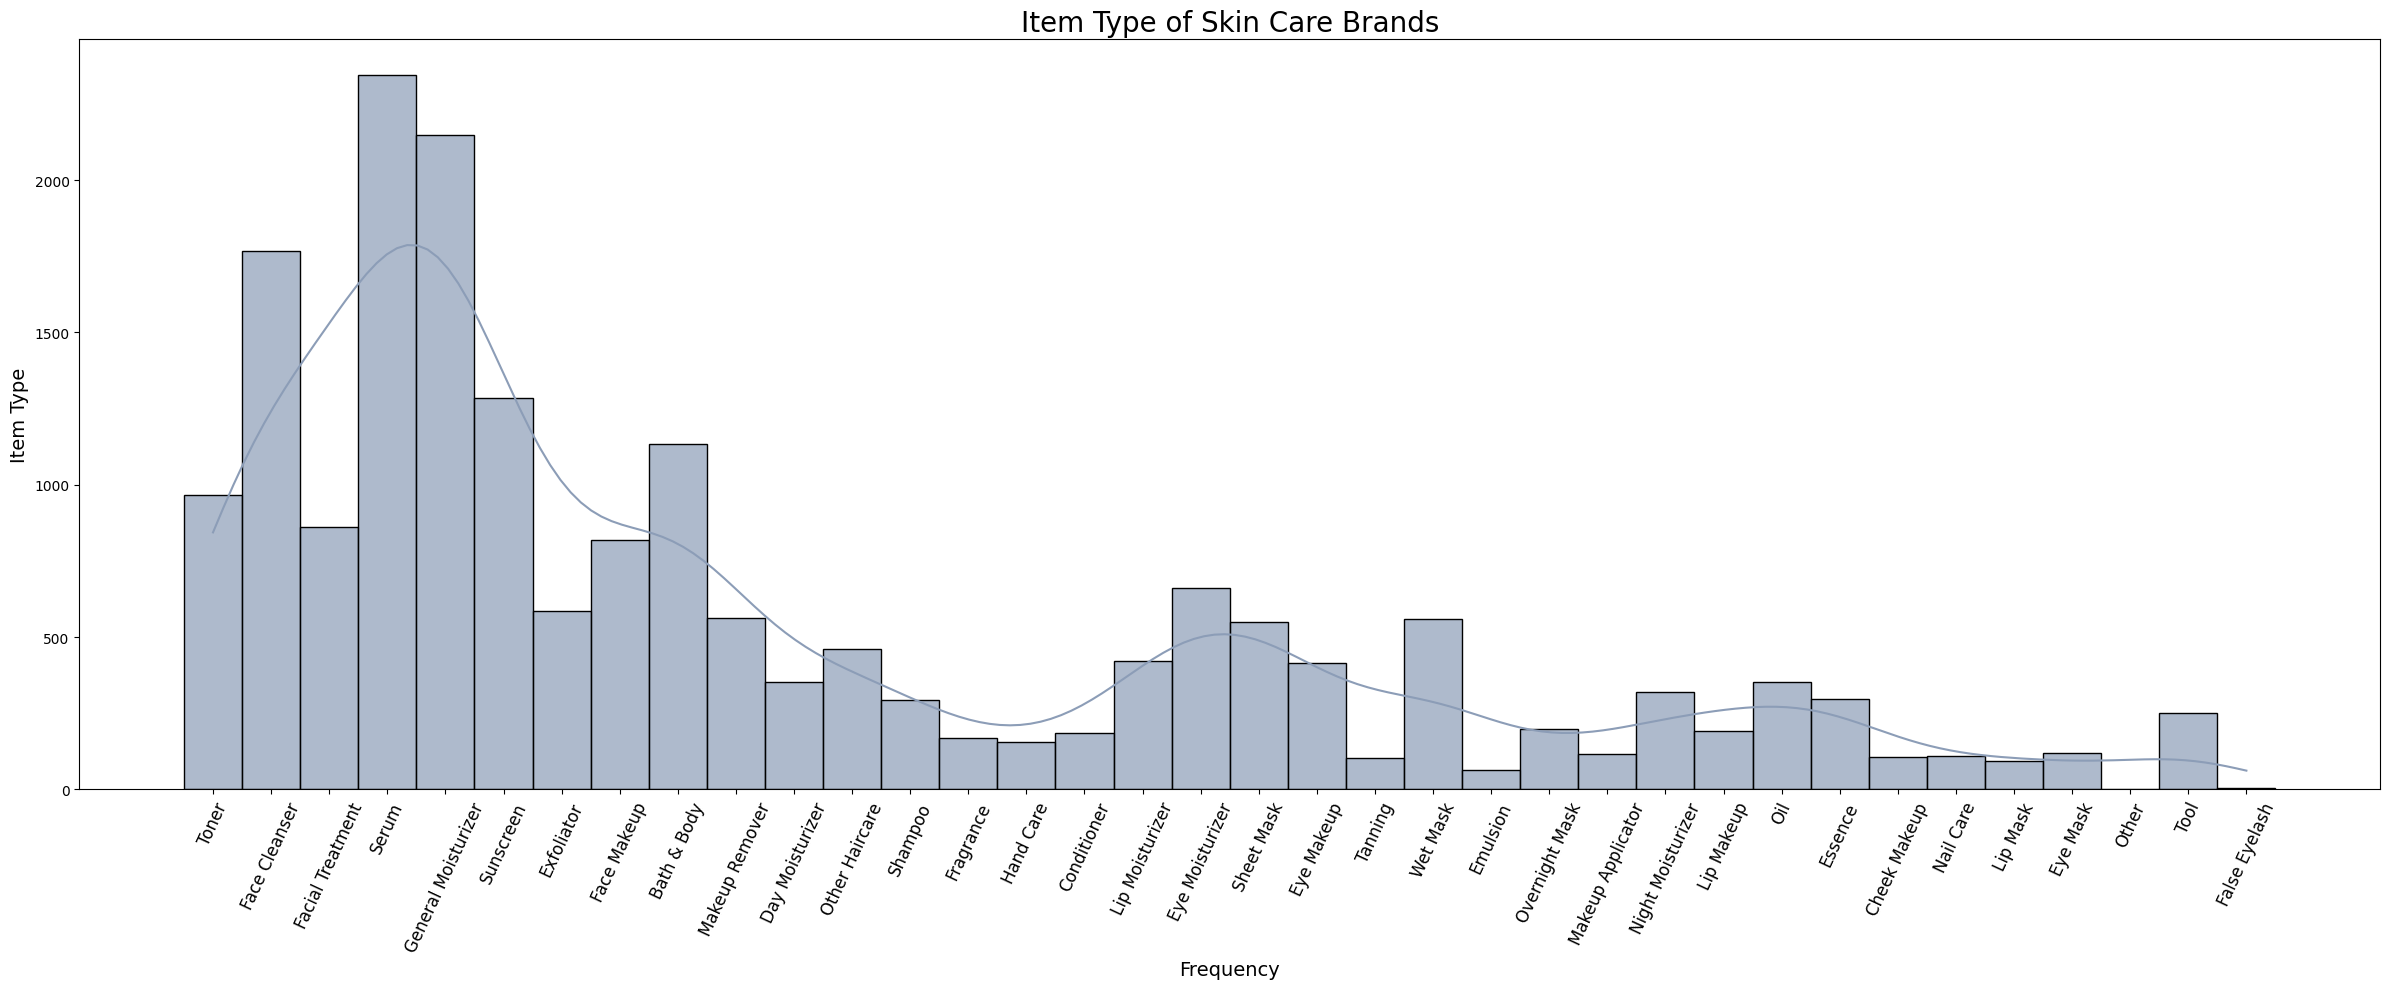

In [91]:
# 카테고리 분포
plt.figure(figsize=(24,10))
sns.histplot(data=skinsort_copy['type'], bins=31, alpha=0.7, color='#8C9DB7', kde=True)
plt.title('Item Type of Skin Care Brands', fontsize=20)

plt.xticks(rotation=65, fontsize=12)
plt.xlabel('Frequency', fontsize=14)
plt.ylabel('Item Type', fontsize=14)

plt.tight_layout()
plt.show()

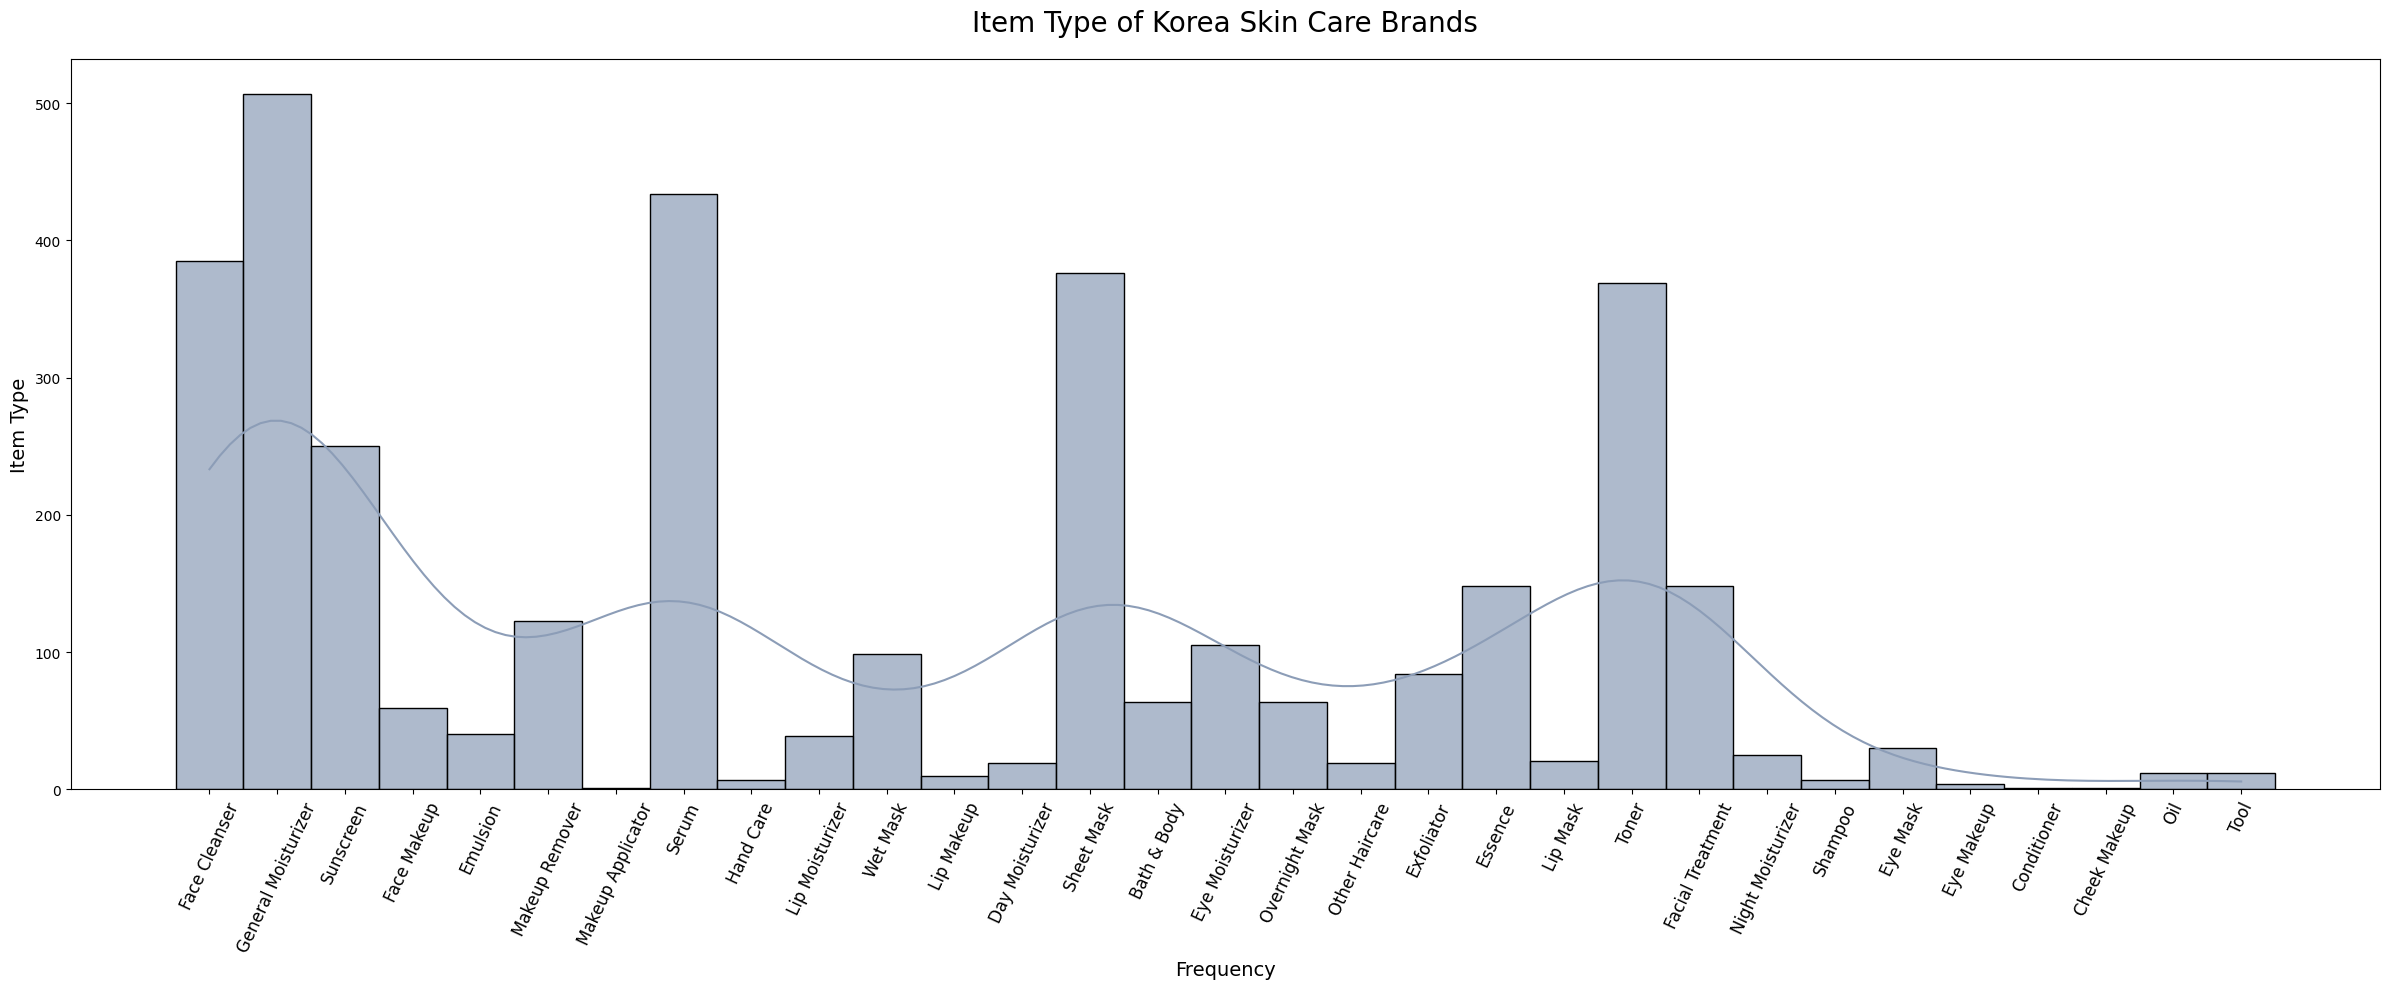

In [92]:
# 한국 스킨케어 브랜드들의 제품 타입 분포
query_cond = "country == 'South Korea'"
k_skin_brand = skinsort_copy.query(query_cond).reset_index()
k_skin_brand.drop(columns='index', inplace=True)
k_skin_brand.head(2)

plt.figure(figsize=(24,10))

sns.histplot(data=k_skin_brand['type'], bins=31, alpha=0.7, color='#8C9DB7', kde=True)
plt.title('Item Type of Korea Skin Care Brands', fontsize=20, pad=20)

plt.xticks(rotation=65, fontsize=12)
plt.xlabel('Frequency', fontsize=14)
plt.ylabel('Item Type', fontsize=14)

plt.tight_layout()
plt.show()

> Skinsort 한국 스킨케어 브랜드의 제품 유형 분포
- 일반적으로 알고 있는 것과 비슷함. general moisture, serum, sheet mask, toner 등 기초 제품들과 마스크팩이 많음 !

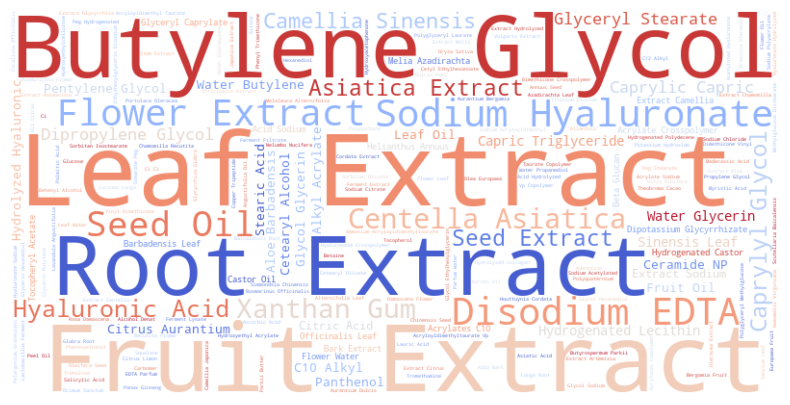

In [93]:
# 한국 스킨케어 브랜드 성분
from wordcloud import WordCloud

wordcloud = WordCloud(width=800, height=400, 
    background_color='white', colormap='coolwarm').generate(' '.join(k_skin_brand['ingridients'].dropna()))
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
# plt.title("Word Cloud - Item Review")
plt.show()

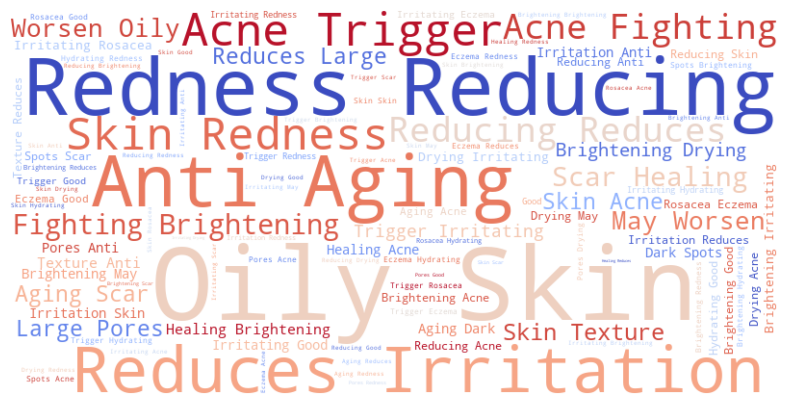

In [94]:
# 한국 스킨케어 브랜드 - 사용후
from wordcloud import WordCloud

wordcloud = WordCloud(width=800, height=400, 
    background_color='white', colormap='coolwarm').generate(' '.join(k_skin_brand['afterUse'].dropna()))
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
# plt.title("Word Cloud - Item Review")
plt.show()

> 사용 후 반응
- 피부 타입 개인 차에 따른 반응들이 여기도 많음. 더 기름이 심해졌다, 건조하다 등
- 간지러움, 붉어짐 등 -> 개인적인 생각이지만 너무 특이한 성분? 약초나 시카 성분 등 자연성분을 강조한다고 너무 특이한 게 들어가면 개인 차를 많이 타는 것 같음

# PART 3: Data Analysis

### ◼ Amazon

#### Sentiment Analysis

In [39]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Create an instance of SentimentIntensityAnalyzer, which is part of the VADER sentiment analysis tool.
analyzer = SentimentIntensityAnalyzer()

# Function to apply VADER sentiment analysis to each review.
# The function takes in a 'review' (text) and returns the polarity scores, which include
# 'compound', 'positive', 'negative', and 'neutral' sentiment values.
def get_sentiment(review):
    return analyzer.polarity_scores(review)

# Apply the 'get_sentiment' function to each entry in the 'Cleaned_Review' column.
# Store the resulting sentiment scores (dictionary) in a new column 'vader_scores'.
amazon_df['cleaned_review'] = amazon_df['cleaned_review'].astype(str)
amazon_df['vader_scores'] = amazon_df['cleaned_review'].apply(get_sentiment)

k_skin_brand['afterUse'] = k_skin_brand['afterUse'].astype(str)
k_skin_brand['vader_scores'] = k_skin_brand['afterUse'].apply(get_sentiment)

# Extract the 'compound' score from the 'vader_scores' dictionary for each review.
# The 'compound' score is a normalized score ranging from -1 (most negative) to +1 (most positive),
# summarizing the overall sentiment of the text.
amazon_df['compound'] = amazon_df['vader_scores'].apply(lambda score_dict: score_dict['compound'])
k_skin_brand['compound'] = k_skin_brand['vader_scores'].apply(lambda score_dict: score_dict['compound'])

# Function to classify the sentiment based on the 'compound' score.
# Scores >= 0.05 are classified as 'Positive', <= -0.05 as 'Negative', and anything in between as 'Neutral'.
def classify_sentiment(compound_score):
    if compound_score >= 0.05:
        return 'Positive'
    elif compound_score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

# Apply the 'classify_sentiment' function to the 'compound' score to get the overall sentiment
# classification (Positive, Negative, or Neutral) for each review.
amazon_df['sentiment'] = amazon_df['compound'].apply(classify_sentiment)
k_skin_brand['sentiment'] = k_skin_brand['compound'].apply(classify_sentiment)

# Display the first few rows of the DataFrame, showing the cleaned review text,
# the 'compound' sentiment score, and the classified 'sentiment'.
print(amazon_df[['cleaned_review', 'compound', 'sentiment']].head(2))

                                      cleaned_review  compound sentiment
0  i love this moisturizer it feels so nice on yo...    0.9187  Positive
1  amazing for skin smoothing and wrinkle reducti...    0.9666  Positive


C:\Users\miseu\AppData\Local\Temp\ipykernel_10552\2818369362.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\miseu\AppData\Local\Temp\ipykernel_10552\2818369362.py:5: UserWarning:

The palette list has more values (6) than needed (3), which may not be intended.



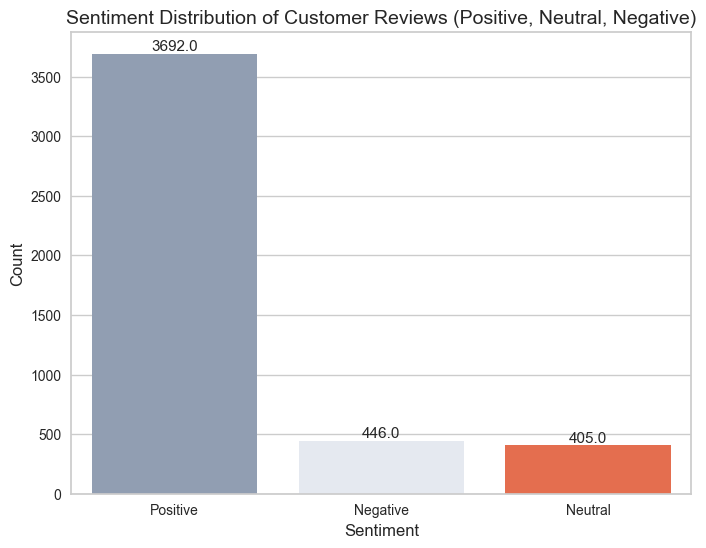

In [ ]:
# 아마존
# Assuming df is already loaded and contains the 'sentiment' column
plt.figure(figsize=(8, 6))

# Count plot with a specific color palette
sns.countplot(data=amazon_df, x='sentiment', palette=skin_palette)

# Add title and axis labels with adjusted font sizes
plt.title('Sentiment Distribution of Customer Reviews (Positive, Neutral, Negative)', fontsize=14)
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Adding data labels on top of the bars
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2, p.get_height()), 
                    ha='center', va='bottom', fontsize=11)

# Display the plot
plt.show()

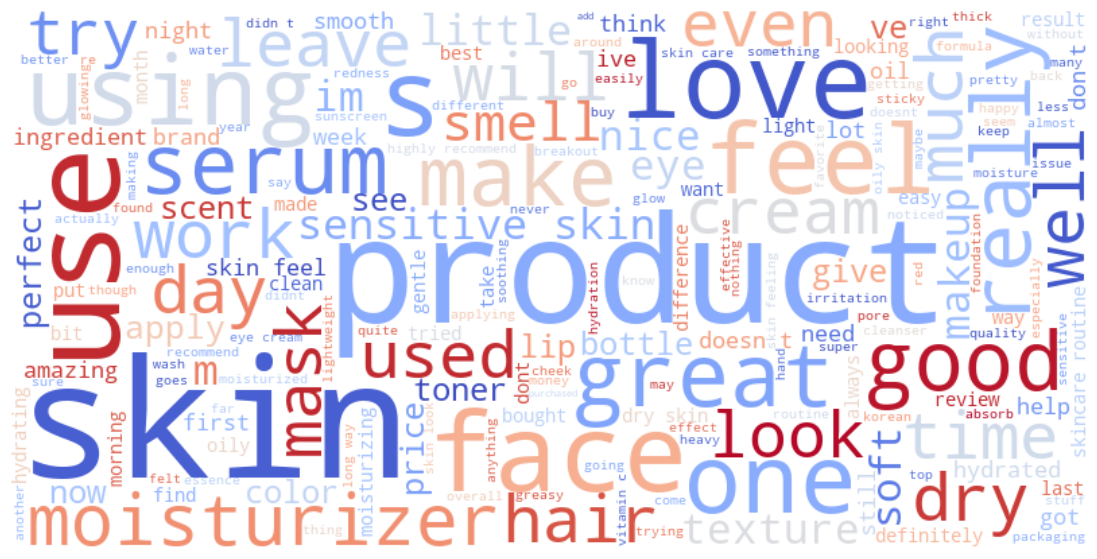

In [41]:
# 긍정적 리뷰 내용 - 워드 클라우드
query_cond = 'sentiment == "Positive"'
pos_df = amazon_df.query(query_cond)
pos_df.reset_index(drop=True, inplace=True)

wordcloud = WordCloud(width=800, height=400, 
                      background_color='white', colormap='coolwarm').generate(' '.join(pos_df['cleaned_review'].dropna()))
plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
# plt.title("Word Cloud - Item Title")
plt.show()

> 긍정 리뷰
- 수분 : hydration, hydrated, moisturing, moisture 
- 카테고리 : skin-care, make-up (카테고리인지, 메이크업할 때 잘 먹는다는 건지는 원본을 봐야알듯)
            skin, skin-care, skincare routine 등이 많음
- 아이템 : oil, serum, cleanser, toner, cream
- 시간 : morning, night ..
    
    - 스킨케어 루틴 중에 일상적으로 이용, 수분감 등 기능성에 긍정적 반응이 주로 (현재 샘플 데이터 기준)
    현재, K-beauty 의 경우 Skin care 쪽으로 미국에서 반응이 좋은데 이 부분과 일치하는 리뷰 내용임.

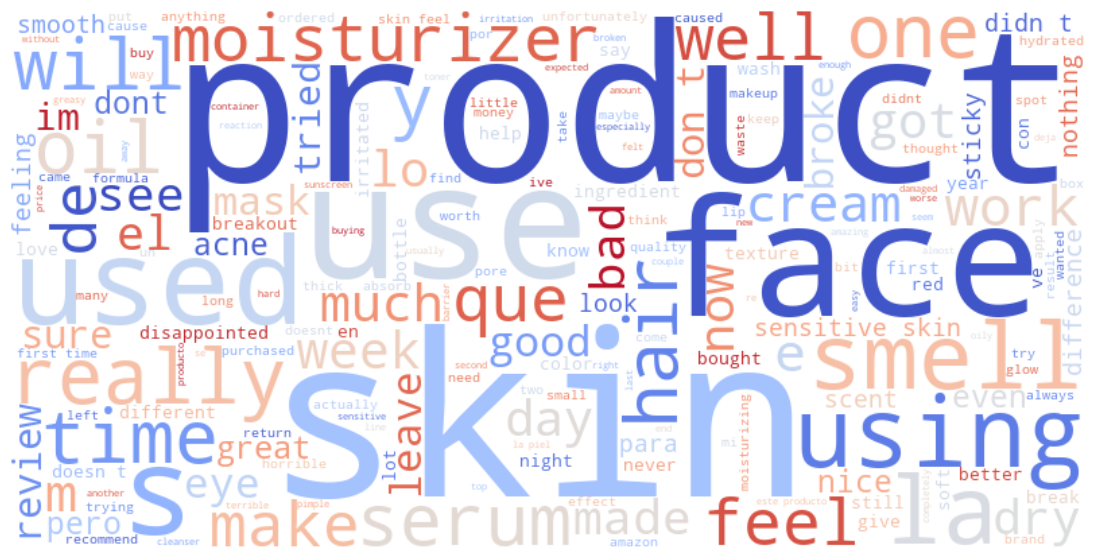

In [42]:
# 부정정적 리뷰 내용 - 워드 클라우드
query_cond = 'sentiment == "Negative"'
neg_df = amazon_df.query(query_cond)
neg_df.reset_index(drop=True, inplace=True)

wordcloud = WordCloud(width=800, height=400, 
                      background_color='white', colormap='coolwarm').generate(' '.join(neg_df['cleaned_review'].dropna()))
plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
# plt.title("Word Cloud - Item Title")
plt.show()

> 부정 리뷰
- dry <-> sticky, expected (기대치에 떨어진듯), money (돈이 아깝다는 건지, 비싸다는 건지 리뷰 원본 봐야됨), waste, damaged (제품 패키지가 손상? 본인의 피부가 손상?), horrible..

    - 건조하다 <-> 끈적거린다 : 이거는 고객 피부 타입별로 맞춤형 필요해보임
        waste, damaged, horrible 등 최악의 평가를 받은 리뷰는 내용 확인해볼 필요 있어보임.

C:\Users\miseu\AppData\Local\Temp\ipykernel_10552\1203212807.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\miseu\AppData\Local\Temp\ipykernel_10552\1203212807.py:6: UserWarning:

The palette list has more values (6) than needed (3), which may not be intended.



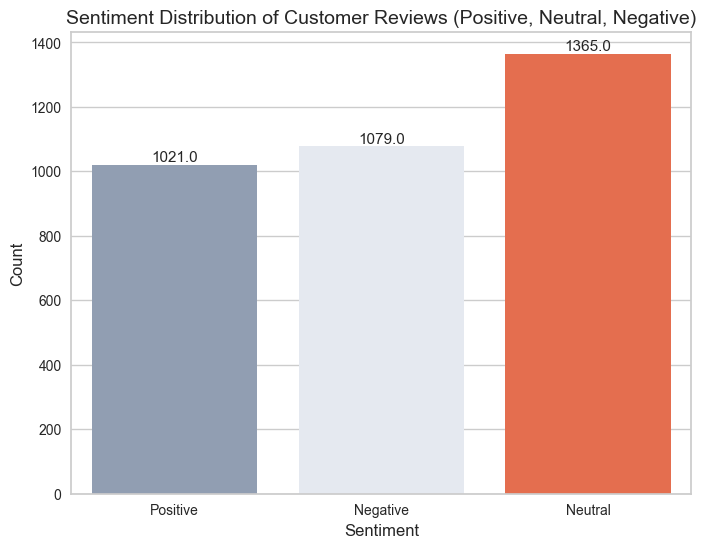

In [43]:
# 스킨쏘트
# Assuming df is already loaded and contains the 'sentiment' column
plt.figure(figsize=(8, 6))

# Count plot with a specific color palette
sns.countplot(data=k_skin_brand, x='sentiment', palette=skin_palette)

# Add title and axis labels with adjusted font sizes
plt.title('Sentiment Distribution of Customer Reviews (Positive, Neutral, Negative)', fontsize=14)
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Adding data labels on top of the bars
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2, p.get_height()), 
                       ha='center', va='bottom', fontsize=11)

# Display the plot
plt.show()

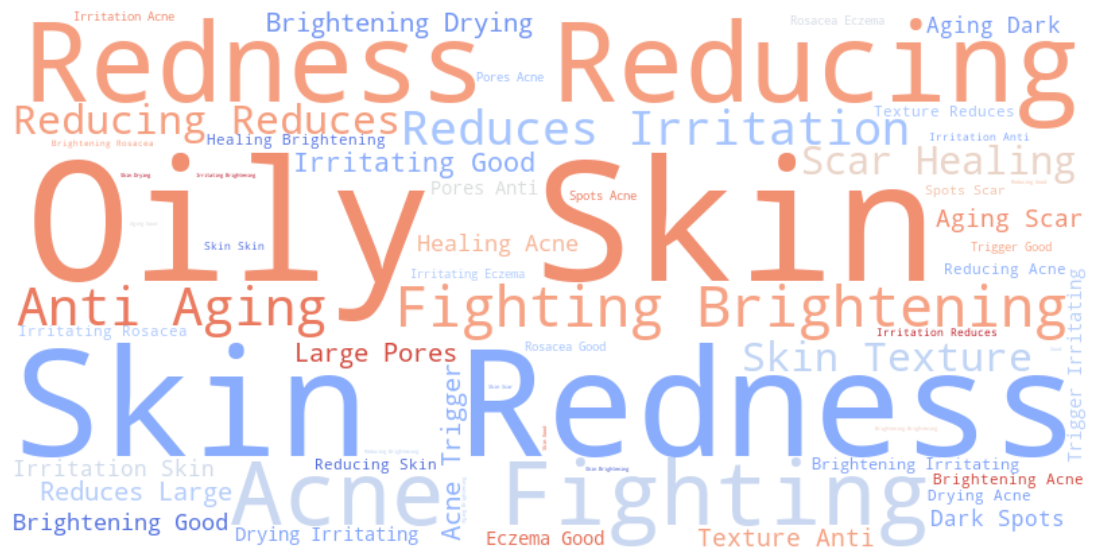

In [45]:
# 긍정적 리뷰 내용 - 워드 클라우드
query_cond = 'sentiment == "Positive"'
pos_df = k_skin_brand.query(query_cond)
pos_df.reset_index(drop=True, inplace=True)

wordcloud = WordCloud(width=800, height=400, 
                      background_color='white', colormap='coolwarm').generate(' '.join(pos_df['afterUse'].dropna()))
plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
# plt.title("Word Cloud - Item Title")
plt.show()

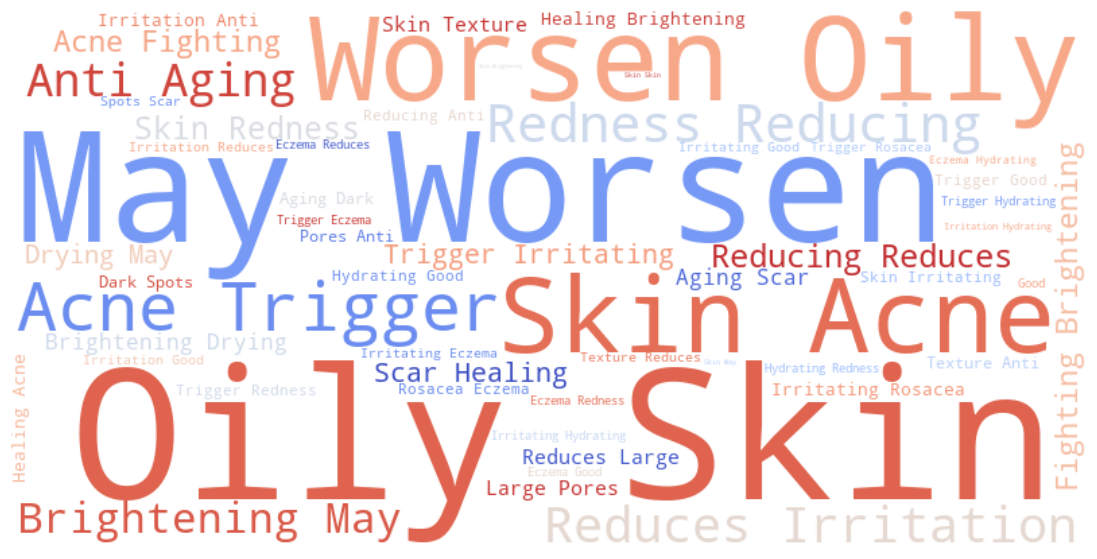

In [46]:
# 부정적 리뷰 내용 - 워드 클라우드
query_cond = 'sentiment == "Negative"'
pos_df = k_skin_brand.query(query_cond)
pos_df.reset_index(drop=True, inplace=True)

wordcloud = WordCloud(width=800, height=400, 
                      background_color='white', colormap='coolwarm').generate(' '.join(pos_df['afterUse'].dropna()))
plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
# plt.title("Word Cloud - Item Title")
plt.show()

#### Topic Modeling

https://towardsdatascience.com/end-to-end-topic-modeling-in-python-latent-dirichlet-allocation-lda-35ce4ed6b3e0

In [ ]:
# stop_words = stopwords.words('english')
# stop_words.extend(['from', 'subject', 're', 'edu', 'use'])

# def sent_to_words(sentences):
#     for sentence in sentences:
#         # deacc=True removes punctuations
#         yield(gensim.utils.simple_preprocess(str(sentence), deacc=True))
        
# def remove_stopwords(texts):
#     return [[word for word in simple_preprocess(str(doc)) 
#              if word not in stop_words] for doc in texts]
    
# data = papers.paper_text_processed.values.tolist()
# data_words = list(sent_to_words(data))
# # remove stop words
# data_words = remove_stopwords(data_words)
# print(data_words[:1][0][:30])

# import gensim.corpora as corpora
# # Create Dictionary
# id2word = corpora.Dictionary(data_words)
# # Create Corpus
# texts = data_words
# # Term Document Frequency
# corpus = [id2word.doc2bow(text) for text in texts]
# # View
# print(corpus[:1][0][:30])

# from pprint import pprint
# # number of topics
# num_topics = 10
# # Build LDA model
# lda_model = gensim.models.LdaMulticore(corpus=corpus,
#                                        id2word=id2word,
#                                        num_topics=num_topics)
# # Print the Keyword in the 10 topics
# pprint(lda_model.print_topics())
# doc_lda = lda_model[corpus]

In [ ]:
# import pyLDAvis.gensim
# import pickle 
# import pyLDAvis
# # Visualize the topics
# pyLDAvis.enable_notebook()
# LDAvis_data_filepath = os.path.join('./results/ldavis_prepared_'+str(num_topics))
# # # this is a bit time consuming - make the if statement True
# # # if you want to execute visualization prep yourself
# if 1 == 1:
#     LDAvis_prepared = pyLDAvis.gensim.prepare(lda_model, corpus, id2word)
#     with open(LDAvis_data_filepath, 'wb') as f:
#         pickle.dump(LDAvis_prepared, f)
# # load the pre-prepared pyLDAvis data from disk
# with open(LDAvis_data_filepath, 'rb') as f:
#     LDAvis_prepared = pickle.load(f)
# pyLDAvis.save_html(LDAvis_prepared, './results/ldavis_prepared_'+ str(num_topics) +'.html')
# LDAvis_prepared

### ◼ Skinsort

#### K-means Clustering

In [25]:
k_skin_brand.columns

Index(['brand', 'name', 'type', 'country', 'ingridients', 'afterUse'], dtype='object')

In [26]:
# 클러스터링 할 컬럼 지정
feature_names=['type','ingridients', 'afterUse']

# 지정된 컬럼으로 새로운 dataframe 생성 
base_df = pd.DataFrame(k_skin_brand, columns=feature_names)

In [30]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

df = base_df

# TF-IDF 벡터화 객체 생성
tfidf_vectorizer = TfidfVectorizer(
    max_features=10,  # 각 컬럼에서 최대 10개의 중요한 단어 선택
    stop_words="english",  # 불용어 제거
    ngram_range=(1, 2)  # 1~2그램 사용
)

# 컬럼별 TF-IDF 변환
tfidf_results = {}
for column in feature_names:
    # NaN 제거 후 TF-IDF 적용
    tfidf_matrix = tfidf_vectorizer.fit_transform(df[column].dropna())
    
    # TF-IDF 결과를 데이터프레임으로 저장
    tfidf_results[column] = pd.DataFrame(
        tfidf_matrix.toarray(),
        columns=[f"{column}_{feature}" for feature in tfidf_vectorizer.get_feature_names_out()]
    )

# 결과 병합 (컬럼 이름으로 구분된 TF-IDF 결과)
final_tfidf_df = pd.concat(tfidf_results.values(), axis=1)


   type_cleanser  type_face  type_face cleanser  type_general  \
0       0.585916   0.559826            0.585916      0.000000   
1       0.000000   0.000000            0.000000      0.598048   
2       0.000000   0.000000            0.000000      0.000000   
3       0.000000   0.000000            0.000000      0.000000   
4       0.000000   0.000000            0.000000      0.000000   

   type_general moisturizer  type_mask  type_moisturizer  type_serum  \
0                  0.000000        0.0          0.000000         0.0   
1                  0.598048        0.0          0.533552         0.0   
2                  0.000000        0.0          0.000000         0.0   
3                  0.000000        0.0          0.000000         0.0   
4                  0.000000        0.0          0.000000         0.0   

   type_sheet  type_sheet mask  ingridients_acid  ingridients_extract  \
0         0.0              0.0          0.101915             0.562369   
1         0.0              0.0

In [35]:
# 표준화
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
imputed_scale_df = imputer.fit_transform(final_tfidf_df)

# 표준화 방식: standard scaler (평균0, 분산1)
std_scale_df = StandardScaler().fit_transform(imputed_scale_df)

In [46]:
# 주성분 개수를 판단하기 위한 pca임의 시행 
pca = PCA(n_components=6)
pca.fit(std_scale_df)
# 설정한 주성분의 갯수로 전체 데이터 분산을 얼만큼 설명 가능한지 
pca.explained_variance_ratio_.sum()

0.5648239277895504

In [37]:
# pca 시행
pca_df = pca.fit_transform(std_scale_df)
pca_df = pd.DataFrame(data = pca_df, columns = ['PC1','PC2','PC3'])  

# Show the first 5 firms
pca_df.head()

,PC1,PC2,PC3
0,-4.056019,-2.197353,-0.704073
1,1.174595,2.989304,-2.564606
2,0.458425,0.767791,-0.125748
3,-2.559555,1.759478,1.832608
4,-0.852793,1.367042,0.218699


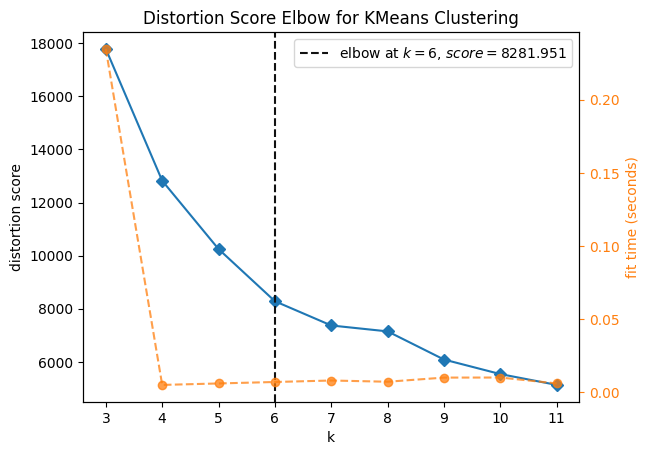

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [38]:
# 초기 k 값 참고를 위한 scree plot 을 그리고, 군집이 나뉘는 시간까지 고려한 k 값 확인 
model = KMeans()

# k 값의 범위를 조정해 줄 수 있습니다. 
visualizer = KElbowVisualizer(model, k=(3,12))

# 데이터 적용 
visualizer.fit(pca_df) 
visualizer.show()   

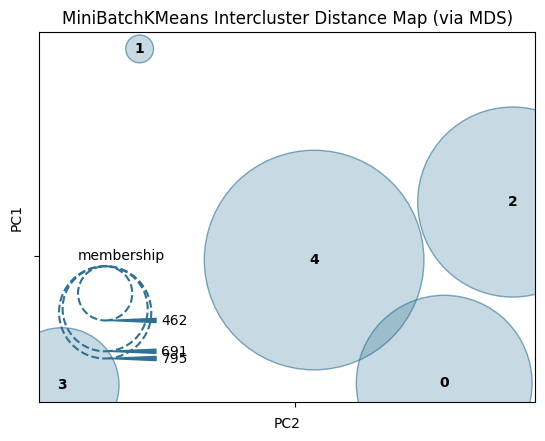

InterclusterDistance(ax=<Axes: title={'center': 'MiniBatchKMeans Intercluster Distance Map (via MDS)'}, xlabel='PC2', ylabel='PC1'>,
                     estimator=MiniBatchKMeans(n_clusters=5, random_state=42))

In [39]:
# 초기 k 값 참고를 위한 distance map 시각화
#그룹의 갯수를 지정해 줄 수 있습니다. 저는 5로 적어두었습니다. 
intercluster_distance(MiniBatchKMeans(5, random_state=42), pca_df)

In [40]:
#  KMEANS
# 군집개수(n_cluster)는 5,초기 중심 설정방식 랜덤,  
kmeans = KMeans(n_clusters=5, random_state=42, init='random')

# pca df 를 이용한 kmeans 알고리즘 적용
kmeans.fit(pca_df)

# 클러스터 번호 가져오기 
labels = kmeans.labels_

# 클러스터 번호가 할당된 데이터셋 생성
kmeans_df = pd.concat([pca_df, pd.DataFrame({'Cluster':labels})],axis = 1)

In [41]:
# 클러스터 번호가 할당된 데이터셋 생성
kmeans_df.groupby(['Cluster'])['PC1'].count().reset_index()

,Cluster,PC1
0,0,404
1,1,1360
2,2,521
3,3,451
4,4,727


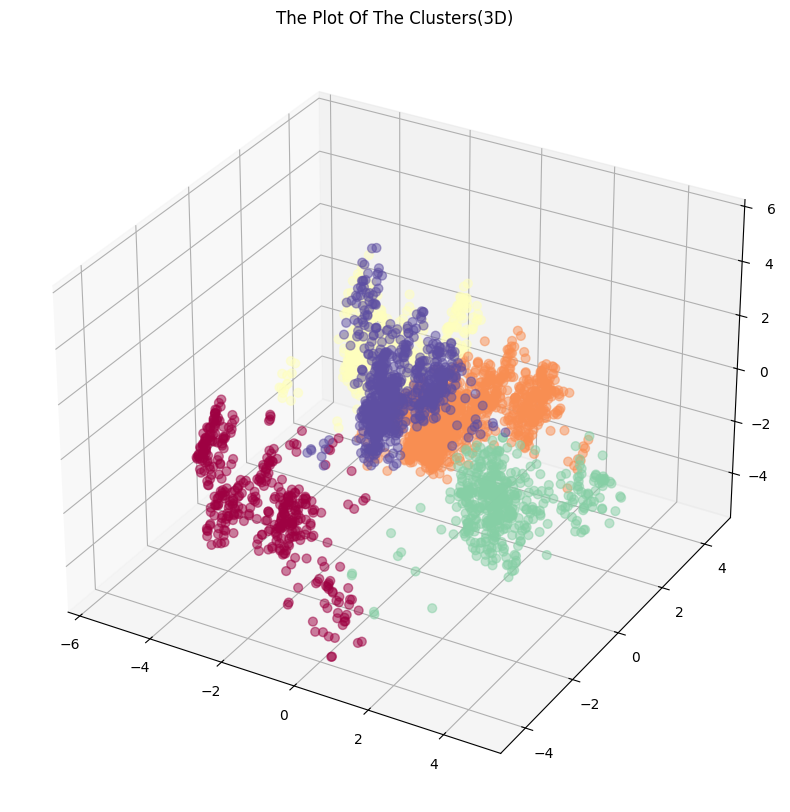

In [43]:
# 3차원으로 시각화 
x =kmeans_df["PC1"]
y =kmeans_df["PC2"]
z =kmeans_df["PC3"]

fig = plt.figure(figsize=(12,10))
ax = plt.subplot(111, projection='3d')
ax.scatter(x, y, z, s=40, c=kmeans_df["Cluster"], marker='o', alpha = 0.5, cmap = 'Spectral')
ax.set_title("The Plot Of The Clusters(3D)")

plt.show()

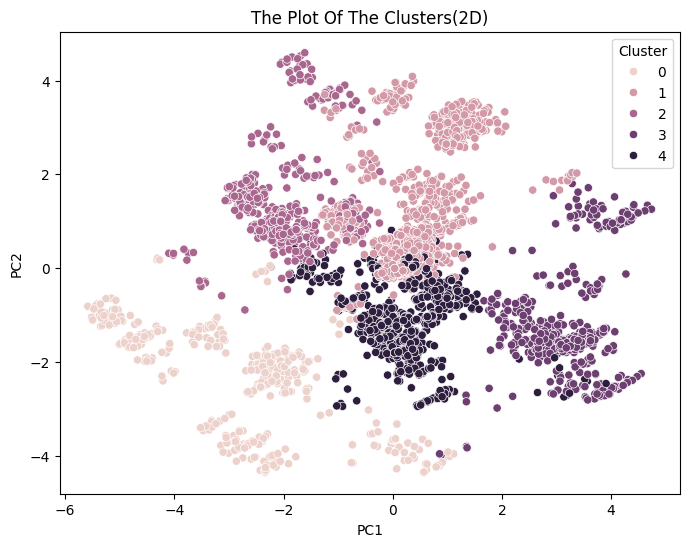

In [44]:
# 2차원으로 시각화

plt.figure(figsize=(8,6))

sns.scatterplot(data = kmeans_df, x = 'PC1', y='PC2', hue='Cluster')
plt.title('The Plot Of The Clusters(2D)')
plt.show()

# PART 5: LLM chatbot

https://teddylee777.github.io/langchain/rag-tutorial/